In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

import torch

! pip install scikit-learn==1.8.0
import sklearn
sklearn.set_config(enable_metadata_routing=True)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from pandas.api.types import CategoricalDtype

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

! pip install fairlearn
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import true_positive_rate, true_negative_rate, false_positive_rate, false_negative_rate, selection_rate

from fairlearn.metrics import MetricFrame

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,581 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and dire

In [2]:
import os
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
os.chdir("/content/drive/MyDrive/3. Grad School/리스크 관리 경진대회")

#### 데이터, 모델 불러오기

In [5]:
data = pd.read_pickle("DATA/Health_Insurance_final.pkl")

In [6]:
target = 'is_churn'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]

der_cols = [
    'missing_geo_cxt',       # 지역 결측 신호
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',   # 가격 인상 압박(비율 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

print(f"사용 변수 개수(기본) : {len(x_cols)}")
print(f"사용 변수 개수(파생) : {len(der_cols)}")
x_cols += der_cols
print(f"최종 변수 개수 : {len(x_cols)}개")

# device = "cuda" if torch.cuda.is_available() else "cpu"

사용 변수 개수(기본) : 15
사용 변수 개수(파생) : 7
최종 변수 개수 : 22개


In [7]:
### Encoding
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']

In [8]:
model_data = pd.read_pickle("Model/churn_model_glm_final.pkl")
model = model_data['model']
threshold = model_data['threshold']
features = model_data['features']
best_params = model_data['best_params']

In [9]:
train = data[data['period'].isin([2017, 2018])]
val = data[data['period'] == 2018]
test = data[data['period'] == 2019]

x_train = train[x_cols]
y_train = train[target]
x_val = val[x_cols]
y_val = val[target]
x_test = test[x_cols]
y_test = test[target]

x_train[cat_cols] = x_train[cat_cols].astype(str)
x_val[cat_cols] = x_val[cat_cols].astype(str)
x_test[cat_cols] = x_test[cat_cols].astype(str)

num_cols = [col for col in x_cols if col not in cat_cols]

# 수치형 변수들을 강제로 숫자형으로 변환 (에러 발생 시 NaN으로 처리)
for col in num_cols:
    x_train[col] = pd.to_numeric(x_train[col], errors='coerce')
    x_val[col] = pd.to_numeric(x_val[col], errors='coerce')
    x_test[col] = pd.to_numeric(x_test[col], errors='coerce')

/tmp/ipykernel_437/3309588252.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[cat_cols] = x_train[cat_cols].astype(str)
/tmp/ipykernel_437/3309588252.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_val[cat_cols] = x_val[cat_cols].astype(str)
/tmp/ipykernel_437/3309588252.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

In [10]:
# # 불균형 데이터 가중치 계산
# spw = (y_train == 0).sum() / (y_train == 1).sum()
device = "cuda" if torch.cuda.is_available() else "cpu"

#### 민감변수 처리

In [11]:
def get_sens_features(var_name, sens_config, x_train = x_train, x_val = x_val, x_test = x_test):
    """특정 변수에 대해 민감변수 속성 생성"""

    if var_name == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name == 'age':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() in ['c_gi', 'c_ie_t']:
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        var_name = var_name.upper()
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name.lower() == 'c_h':
        train_sens = x_train['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        val_sens = x_val['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        test_sens = x_test['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])

    if var_name.lower() == 'age_gender':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        age_train_bin = pd.cut(x_train['age'], bins = bins, labels = labels)
        age_val_bin = pd.cut(x_val['age'], bins = bins, labels = labels)
        age_test_bin = pd.cut(x_test['age'], bins = bins, labels = labels)
        train_sens = pd.DataFrame({'gen_age': x_train['gender'].astype(str) + "_" + age_train_bin.astype(str)})
        val_sens = pd.DataFrame({'gen_age': x_val['gender'].astype(str) + "_" + age_val_bin.astype(str)})
        test_sens = pd.DataFrame({'gen_age': x_test['gender'].astype(str) + "_" + age_test_bin.astype(str)})

    return train_sens, val_sens, test_sens

In [12]:
sens_config = {
    'age':{
        'bins' : [0, 19, 29, 39, 49, 59, 69, 100],
        'labels' : ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    },
    'age_gender':{
        'bins' :  [0, 25, 40, 60, 100],
        'labels' : ['청년', '장년', '중년', '고령']
    },
    'c_gi':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' : ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4']
    },
    'c_ie_t':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' :['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4']
    },
    'c_h':{
        'c_h_map_inv' : {500: 'H1', 5500: 'H2', 17500: 'H3', 37500: 'H4', 75000: 'H5', 150000: 'H6', -1: 'Unknown'}
    }
}

#### 모델링

목적식(Objective Function):

$$min_\theta Loss(y, \hat{y}) + \lambda \cdot Constraint(A, \hat{y})$$



- $Loss(y, \hat{y})$ : 기존의 분류 오차(ex. Logloss). 모델의 정확도를 결정
- $Constraint(A, \hat{y})$ : 공정성 페널티. 집단 A간의 지표 차이가 커질수록 값이 커지는 구조
    - 지표 : Equalized Odds로 설정
- $\lambda$ : 공성성을 얼마나 강력하게 강제할 것인지

In [ ]:
def fit_base_model(x_train, x_test, y_train, y_test, x_test_sensitive, model, threshold):

    # 추론
    y_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # 튜닝 전 결과 출력
    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [공통 임계값]       ")
    print("========================================")
    print(threshold)

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("========================================")
    print("       [학습 전 결과]       ")
    print("========================================")
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    print(f"공통 임계값: {threshold}")
    print(f"\n집단 간 최대 격차 (Max Gap)")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))

    return y_pred

In [ ]:
def fairlearn_model(x_train, y_train, x_test, y_test,
                    x_train_sensitive, x_test_sensitive,
                    base_model, threshold,
                    epsilon = 0.05, n_iter = 30):

    # if hasattr(base_model, 'named_steps'):
    #     base_model.named_steps['model'].set_fit_request(sample_weight=True)
    # else:
    #     base_model.set_fit_request(sample_weight=True)

    num_cols = [col for col in x_cols if col not in cat_cols]

    scaler = StandardScaler().set_fit_request(sample_weight=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, num_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
        ]
    )

    lr = LogisticRegression(solver='liblinear').set_fit_request(sample_weight=True)

    base_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', lr)
    ])

    # 제약 조건 설정
    eo_constraints = EqualizedOdds()

    # Mitigator 정의
    mitigator = ExponentiatedGradient(
        estimator = base_model,
        constraints = eo_constraints,
        eps = epsilon, # 공정성 허용 오차. 작을수록 더 강력하게 차별을 방지 but 정확도 희생
        max_iter = n_iter
    )

    # 재학습
    print("\n⚖️ Fairlearn 재학습 중...")
    mitigator.fit(x_train, y_train, sensitive_features = x_train_sensitive)

    # 예측
    y_pred_mit = mitigator.predict(x_test)
    y_prob_mit = mitigator._pmf_predict(x_test)[:, 1]

    aucpr = average_precision_score(y_test, y_prob_mit)
    f1 = f1_score(y_test, y_pred_mit)
    precision = precision_score(y_test, y_pred_mit)
    recall = recall_score(y_test, y_pred_mit)
    print("========================================")
    print("       [Fairlearn 모델 1차 학습 성능 결과]        ")
    print("========================================")
    print(f"F1-Score: {f1:.4f}")
    print(f"PR-AUC: {aucpr:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")

    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred_mit,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))

    return mitigator, y_pred_mit, y_prob_mit

In [ ]:
def threshold_tuning(mitigator, x_val, y_val, x_test, y_test,
                     x_val_sensitive, x_test_sensitive):

    # val 확률 (threshold 계산용) - weighted 방식
    y_val_prob = np.zeros(len(x_val))
    for est, weight in zip(mitigator.predictors_, mitigator.weights_):
        y_val_prob += weight * est.predict_proba(x_val)[:, 1]

    # test 확률 (threshold 적용용) - weighted 방식
    y_prob_mit_weighted = np.zeros(len(x_test))
    for est, weight in zip(mitigator.predictors_, mitigator.weights_):
        y_prob_mit_weighted += weight * est.predict_proba(x_test)[:, 1]

    y_val_pred = mitigator.predict(x_val)

    metrics_dict = {'fpr': false_positive_rate, 'fnr': false_negative_rate}
    mf_val = MetricFrame(metrics = metrics_dict, y_true = y_val, y_pred = y_val_pred, sensitive_features = x_val_sensitive)

    # max gap 기준으로 primary metric 결정
    fpr_gap = mf_val.difference(method='between_groups')['fpr']
    fnr_gap = mf_val.difference(method='between_groups')['fnr']

    if fpr_gap >= fnr_gap:
        primary_metric = 'fpr'
        target_fpr = mf_val.by_group['fpr'].mean()
        target_fnr = mf_val.by_group['fnr'].mean()
        print(f"FPR gap({fpr_gap:.4f}) >= FNR gap({fnr_gap:.4f}) → FPR 우선 최적화")
    else:
        primary_metric = 'tpr'
        target_fpr = mf_val.by_group['fpr'].mean()
        target_fnr = mf_val.by_group['fnr'].mean()
        print(f"FNR gap({fnr_gap:.4f}) > FPR gap({fpr_gap:.4f}) → TPR 우선 최적화")

    print(f"Target FPR: {target_fpr:.4f}, Target FNR: {target_fnr:.4f}")

    thresholds = get_group_thresholds(y_val, y_val_prob, x_val_sensitive, target_fpr, target_fnr, primary_metric = primary_metric)
    y_pred_post = apply_group_thresholds(y_prob_mit_weighted, x_test_sensitive, thresholds)

    # 튜닝 전 FPR 격차
    y_pred_orig = mitigator.predict(x_test)
    mf_before = MetricFrame(metrics = {'fpr': false_positive_rate}, y_true = y_test, y_pred = y_pred_orig, sensitive_features = x_test_sensitive)
    fpr_gap_before = mf_before.difference(method='between_groups')['fpr']

    # 튜닝 후 FPR 격차
    mf_after = MetricFrame(metrics = {'fpr': false_positive_rate}, y_true = y_test, y_pred = y_pred_post, sensitive_features = x_test_sensitive)
    fpr_gap_after = mf_after.difference(method='between_groups')['fpr']

    # 튜닝 후 더 나빠졌으면 원래 예측값 사용
    if fpr_gap_after > fpr_gap_before + 0.01:
        print(f"⚠️ 튜닝 후 FPR 격차가 더 벌어짐 ({fpr_gap_before:.4f} → {fpr_gap_after:.4f}), mitigator 원래 예측값으로 대체합니다.")
        y_pred_post = y_pred_orig

    f1 = f1_score(y_test, y_pred_post)
    pr_auc = average_precision_score(y_test, y_prob_mit_weighted)
    prec = precision_score(y_test, y_pred_post)
    rec = recall_score(y_test, y_pred_post)

    print("========================================")
    print("       [최종 모델 전체 성능 결과]        ")
    print("========================================")
    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    metrics_final = {
        'selection_rate': selection_rate,
        'tpr': true_positive_rate,
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics_final,
        y_true = y_test,
        y_pred = y_pred_post,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [최종 - 집단별 임계값]       ")
    print("========================================")
    for group, thr in thresholds.items():
        print(f"Group {group}: {thr:.4f}")

    print("\n========================================")
    print("       [최종 - 연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [최종 - 집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")
    print(mf.difference(method='between_groups'))

    return thresholds, y_pred_post


def apply_group_thresholds(y_prob_mit, x_train_sensitive, group_thresholds):
    y_prob_mit = np.array(y_prob_mit)
    x_train_sensitive = np.array(x_train_sensitive).flatten()

    y_pred_post = np.zeros_like(y_prob_mit, dtype = int)
    for group, thr in group_thresholds.items():
        mask = (x_train_sensitive == group)
        y_pred_post[mask] = (y_prob_mit[mask] >= thr).astype(int)
    return y_pred_post


def get_group_thresholds(y_true, y_prob, sensitive_features, target_fpr, target_fnr, primary_metric = 'fpr'):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    sensitive_features = np.array(sensitive_features).flatten()

    group_thresholds = {}
    groups = np.unique(sensitive_features)
    target_tpr = 1 - target_fnr

    plt.figure(figsize = (10, 6))

    for group in groups:
        mask = (sensitive_features == group)

        if len(np.unique(y_prob[mask])) <= 2:
            print(f"‼️{group} : 이미 최적의 공정한 상태이므로 추가 튜닝을 진행하지 않습니다.‼️")
            group_thresholds[group] = 1
            continue

        fpr, tpr, thresholds = roc_curve(y_true[mask], y_prob[mask])
        fnr = 1 - tpr
        thresholds[0] = max(y_prob[mask]) + 1e-9

        # primary metric 기준으로 후보 탐색, secondary metric으로 최적화
        tolerance = 0.008

        if primary_metric == 'fpr':
            # FPR gap이 더 크면 FPR을 우선 맞추고, 후보 중 TPR이 target에 가장 가까운 것 선택
            candidates = np.where(np.abs(fpr - target_fpr) <= tolerance)[0]
            if len(candidates) == 0:
                idx = np.argmin(np.abs(fpr - target_fpr))
            else:
                idx = candidates[np.argmin(np.abs(tpr[candidates] - target_tpr))]

        else:  # primary_metric == 'tpr'
            # TPR gap이 더 크면 TPR을 우선 맞추고, 후보 중 FPR이 target에 가장 가까운 것 선택
            candidates = np.where(np.abs(tpr - target_tpr) <= tolerance)[0]
            if len(candidates) == 0:
                idx = np.argmin(np.abs(tpr - target_tpr))
            else:
                idx = candidates[np.argmin(np.abs(fpr[candidates] - target_fpr))]

        group_thr = thresholds[idx]
        group_thresholds[group] = float(np.clip(group_thr, 0.0, 1.0))

        plt.plot(fpr, tpr, label = f'Group {group} (Thr: {group_thr:.4f})')
        plt.scatter(target_fpr, np.interp(target_fpr, fpr, tpr), marker='o')

    plt.axvline(x = target_fpr, color = 'red', linestyle = '--', label = f'Target FPR ({target_fpr:.4f})')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curves by Group (Primary: {primary_metric.upper()}, Target FPR = {target_fpr:.4f})')
    plt.legend()
    plt.grid(True)
    plt.show()

    return group_thresholds

In [ ]:
class FairlearnModelCheck():
    def __init__(self, x_train, y_train, x_val, y_val, x_test, y_test,
                 base_model, threshold,
                 x_train_sensitive, x_val_sensitive, x_test_sensitive,
                 epsilon, n_iter):
        self.x_train = x_train
        self.y_train = y_train
        self.x_val = x_val
        self.y_val = y_val
        self.x_test = x_test
        self.y_test = y_test
        self.base_model = base_model
        self.threshold = threshold
        self.x_train_sensitive = x_train_sensitive
        self.x_val_sensitive = x_val_sensitive
        self.x_test_sensitive = x_test_sensitive
        self.epsilon = epsilon
        self.n_iter = n_iter

        self.mitigator = None
        self.y_prob_mit = None
        self.thresholds = None

    def run_base_model(self):
        print("="*50)
        print(" [Step 1] Base Model (보정 전) 학습 및 평가")
        print("="*50)
        y_pred_org = fit_base_model(
            self.x_train, self.x_test, self.y_train, self.y_test,
            self.x_test_sensitive,
            self.base_model, self.threshold
        )
        return y_pred_org

    def run_fairlearn(self):
        print("\n" + "="*50)
        print(" [Step 2] Fairlearn Mitigator (1차 보정) 학습")
        print("="*50)
        self.mitigator, y_pred_mit, self.y_prob_mit = fairlearn_model(
            self.x_train, self.y_train, self.x_test, self.y_test,
            self.x_train_sensitive, self.x_test_sensitive,
            self.base_model, self.threshold,
            self.epsilon, self.n_iter
        )
        return y_pred_mit

    def run_fairlearn_tuning(self):
        if self.mitigator is None:
            print("❌ 먼저 run_fairlearn()을 실행해야 합니다.")
            return
        print("\n" + "="*50)
        print(" [Step 3] Post-processing (2차 임계값 튜닝)")
        print("="*50)
        self.thresholds, y_pred_post = threshold_tuning(
            self. mitigator, self.x_val, self.y_val, self.x_test, self.y_test,
            self.x_val_sensitive, self.x_test_sensitive, self.y_prob_mit
        )
        return y_pred_post

    def run_all_process(self):
        """전체 과정을 한 번에 실행"""
        y_pred_org = self.run_base_model()
        y_pred_mit = self.run_fairlearn()
        y_pred_post = self.run_fairlearn_tuning()
        print("\n" + "="*50)
        print(" ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.")
        print("="*50)
        return y_pred_org, y_pred_mit, y_pred_post

#### 임계값 튜닝

In [ ]:
def optimize_thresholds(model, threshold, x_train, y_train, x_val, y_val, x_test, y_test, x_val_sensitive, x_test_sensitive):

    # 추론
    y_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # 튜닝 전 결과 출력
    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [공통 임계값]       ")
    print("========================================")
    print(threshold)

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("========================================")
    print("       [학습 전 결과]       ")
    print("========================================")
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    print(f"공통 임계값: {threshold}")
    print(f"\n집단 간 최대 격차 (Max Gap)")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))


    postprocess_est = ThresholdOptimizer(
        estimator = model,
        constraints = "equalized_odds",
        objective = "accuracy_score",
        prefit = True,
        predict_method = "predict_proba"
    )

    postprocess_est.fit(x_val, y_val, sensitive_features = x_val_sensitive)
    y_pred_post = postprocess_est.predict(x_test, sensitive_features = x_test_sensitive)

    # post-processing 이후 성능 다시 계산
    f1_post = f1_score(y_test, y_pred_post)
    pr_auc_post = average_precision_score(y_test, y_pred_post)
    prec_post = precision_score(y_test, y_pred_post)
    rec_post = recall_score(y_test, y_pred_post)

    print("========================================")
    print("       [최종 모델 전체 성능 결과]        ")
    print("========================================")
    print(f"F1-Score  : {f1_post:.4f}")
    print(f"PR-AUC : {pr_auc_post:.4f}")
    print(f"Recall    : {rec_post:.4f}")
    print(f"Precision : {prec_post:.4f}")


    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred_post,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [집단별 임계값]       ")
    print("========================================")

    thresholds = {}
    for group in np.unique(x_test_sensitive.squeeze()):
        mask = (x_test_sensitive.squeeze() == group)
        group_probs = y_prob[mask]
        group_preds = y_pred_post[mask]

        pos_samples = group_probs[group_preds == 1]
        neg_samples = group_probs[group_preds == 0]

        pos_min = pos_samples.min() if len(pos_samples) > 0 else 1.0
        neg_max = neg_samples.max() if len(neg_samples) > 0 else 0.0

        thresholds[group] = float((pos_min + neg_max) / 2)

        print(f"연령대: {group:7s} | 추정 임계값: {thresholds[group]:.4f}")

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method = 'between_groups'))

    return postprocess_est, y_pred, y_pred_post

In [ ]:
def fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test):
    _, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)

    postprocess_est, y_pred, y_pred_post = optimize_thresholds(model, threshold, x_train, y_train, x_val, y_val, x_test, y_test, x_val_sensitive, x_test_sensitive)

    print("\n" + "="*50)
    print(" [Step 0] Base Model (보정 전) 학습 결과")
    plot_fpr(y_test, y_pred, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred, var_name, x_test_sensitive.squeeze())

    print("\n" + "="*50)
    print(" [Step 3] Base Model (보정 전) 학습 결과")
    plot_fpr(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())

    return y_pred_post

#### 성능 확인, 공정성 지표 확인 함수

In [ ]:
def get_fpr_by_group(y_true, y_pred, group_col, groups):
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    results = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        group = df[df['group'] == name]
        if len(group) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(group['true'], group['pred']).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results.append({"Group": name, "FPR": fpr, "FP_Count":fp, "TN_Count":tn})
    return pd.DataFrame(results)

def plot_fpr_by_group(fpr_results, group_col):
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Group', y='FPR', data=fpr_results, hue='Group', palette='Blues')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=1, labels=[f'{v.get_height()*100:.2f}%' for v in container])

    if group_col in ['age', 'gender']:
        graph_label = group_col.capitalize()
    elif group_col == 'age_gender':
        graph_label = 'Age & Gender'
    else:
        graph_label = group_col.upper()

    plt.title(f'False Positive Rate (FPR) by {graph_label}')
    plt.ylabel('FPR (Predict 1 when Actual 0)')
    plt.show()

def plot_fpr(y_true, y_pred, group_col, groups):
    fpr_results = get_fpr_by_group(y_true, y_pred, group_col, groups)
    plot_fpr_by_group(fpr_results, group_col)

In [ ]:
def get_fairness_summary(y_true, y_pred, group_col, groups):
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    summary = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        temp = df[df['group'] == name]
        if len(temp) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(temp['true'], temp['pred']).ravel()

        # 1. Parity
        parity = (tp + fp) / len(temp)
        # 2. Equalized Odds
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0

        summary.append({
            f'{group_col}'.capitalize(): name,
            'True': round(temp['true'].mean(), 4),
            'Pred': round(temp['pred'].mean(), 4),
            'Parity': round(parity, 4),
            'TPR (Recall)': round(tpr, 4),
            'FPR (False Positive)': round(fpr, 4),
            'Precision': round(precision, 4)
        })

    return pd.DataFrame(summary)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_fairness_heatmap(fairness_summary, group_col):
    styled_df = fairness_summary.style.format({
        'True Rate': '{:.2%}',
        'Pred Rate': '{:.2%}',
        'Parity': '{:.2%}',
        'TPR (Recall)': '{:.2%}',
        'FPR (False Positive)': '{:.2%}',
        'Precision': '{:.2%}'
    })

    cols_to_style = ['True', 'Pred', 'Parity', 'TPR (Recall)', 'FPR (False Positive)', 'Precision']
    for col in cols_to_style:
        styled_df = styled_df.background_gradient(cmap = 'Blues', subset = [col], axis = 0)

    return styled_df

def plot_fairness(y_true, y_pred, group_col, groups):
    fairness_summary = get_fairness_summary(y_true, y_pred, group_col, groups)
    styled_df = plot_fairness_heatmap(fairness_summary, group_col)
    display(styled_df)

### 결과 확인

#### 최종 실행 함수

In [ ]:
def plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive):
    """
    그래프 여러 개 한 번에 그리기
    y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
    """
    x_test_sensitive = x_test_sensitive.squeeze()
    if var_name == 'age_gender':
        groups = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    else:
        groups = np.unique(x_test_sensitive)
    labels = ["Original (No Tuning)", "Mitigation (Step 1)", "Mit+Thresholding (Step 2)", "Auto-Thresholding (Step 3)"]
    # colors = ["#8dbad2", "#f9b282", "#77d18d", "#f08080"]
    colors = ['#B6CCFE',  '#B8E1FF', '#ADE8F4', '#D1D1FF']
    # colors = ['#E2E2FF', '#C1C1FF', '#A0A0FF', '#7F7FFF']

    # fig, axes = plt.subplots(1, 4, figsize = (16, 10))
    # axes = axes.flatten()

    all_fpr_values = []
    plot_data = []

    all_fpr_values = []
    plot_data = []
    for pred in y_preds:
        group_fprs = [false_positive_rate(y_test[x_test_sensitive == g], pred[x_test_sensitive == g]) for g in groups]
        plot_data.append(group_fprs)
        all_fpr_values.extend(group_fprs)

    max_val = max(all_fpr_values)
    y_limit = min(1.0, max_val + 0.08)

    fig, axes = plt.subplots(1, 4, figsize=(22, 8))
    axes = axes.flatten()

    for i, (group_fprs, label, color) in enumerate(zip(plot_data, labels, colors)):
        ax = axes[i]
        bars = ax.bar(groups, group_fprs, color=color, edgecolor='gray', linewidth=1.2, alpha=0.8)

        f_max, f_min = max(group_fprs), min(group_fprs)
        ax.axhline(f_max, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.85)
        ax.axhline(f_min, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.85)

        ax.text(1.07, f_max, 'Max', transform=ax.get_yaxis_transform(), color='#E74C3C', fontsize=9, va='bottom', ha='right', fontweight='bold', clip_on=False)
        ax.text(1.07, f_min, 'Min', transform=ax.get_yaxis_transform(), color='#E74C3C', fontsize=9, va='bottom', ha='right', fontweight='bold', clip_on=False)

        ax.set_title(f"[{i}] {label}", fontsize=14, fontweight='bold', pad=20)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

        ax.set_ylim(0, y_limit)

        # 수치 라벨링
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (y_limit * 0.02),
                    f'{height*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.grid(axis='y', linestyle='--', alpha=0.5)

    if var_name in ['age', 'gender']:
        graph_label = var_name.capitalize()
    elif var_name == 'age_gender':
        graph_label = 'Age & Gender'
    else:
        graph_label = var_name.upper()

    plt.suptitle(f'FPR Distribution Step-by-Step Analysis: {graph_label}', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
def fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        base_model, threshold
        ):

    x_train_sensitive, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)
    epsilon, n_iter = variable_map[var_name]['eps'], variable_map[var_name]['iter']

    checker = FairlearnModelCheck(
        x_train, y_train, x_val, y_val, x_test, y_test,
        base_model, threshold,
        x_train_sensitive, x_val_sensitive, x_test_sensitive,
        epsilon, n_iter)
    y_pred_org, y_pred_mit, y_pred_post = checker.run_all_process()

    print("\n" + "="*50)
    print(" [Step 0] Base Model (보정 전) 학습 결과\n")
    plot_fpr(y_test, y_pred_org, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_org, var_name, x_test_sensitive.squeeze())
    print("="*50)

    print("\n" + "="*50)
    print(" [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과\n")
    plot_fpr(y_test, y_pred_mit, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_mit, var_name, x_test_sensitive.squeeze())
    print("="*50)

    print("\n" + "="*50)
    print(" [Step 2] Post-processing (2차 임계값 튜닝) 결과\n")
    plot_fpr(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())
    print("="*50)

    return x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post

In [ ]:
variable_map = {
    "age": {
        "var_name": 'age',
        "eps": 0.07,
        "iter": 30
    },
    "gender": {
        "var_name": 'gender',
        "eps": 0.05,
        "iter": 20
    },
    "age_gender": {
        "var_name": 'age_gender',
        "eps": 0.08, # 복합 변수는 완화된 제약
        "iter": 50
    },
    "c_h": {
        "var_name": 'c_h',
        "eps": 0.07,
        "iter": 30
    },
    "c_gi": {
        "var_name": 'c_gi',
        "eps": 0.07,
        "iter": 30
    },
    "c_ie_t": {
        "var_name": 'c_ie_t',
        "eps": 0.07,
        "iter": 30
    }
    }

#### 성별

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.510464  0.766641  0.538439  0.461561  0.233359
M             0.592226  0.809464  0.449834  0.550166  0.190536
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.081762
tpr               0.042823
tnr               0.088605
fpr               0.088605
fnr               0.042823
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습

⚖️ Fairlearn 재학습 중...
       [Fairlearn 모델 1차 학습 성능 결과]        
F1-Score: 0.1624
PR-AUC: 0.1997
Recall: 0.0948
Precision: 0.5672

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F        

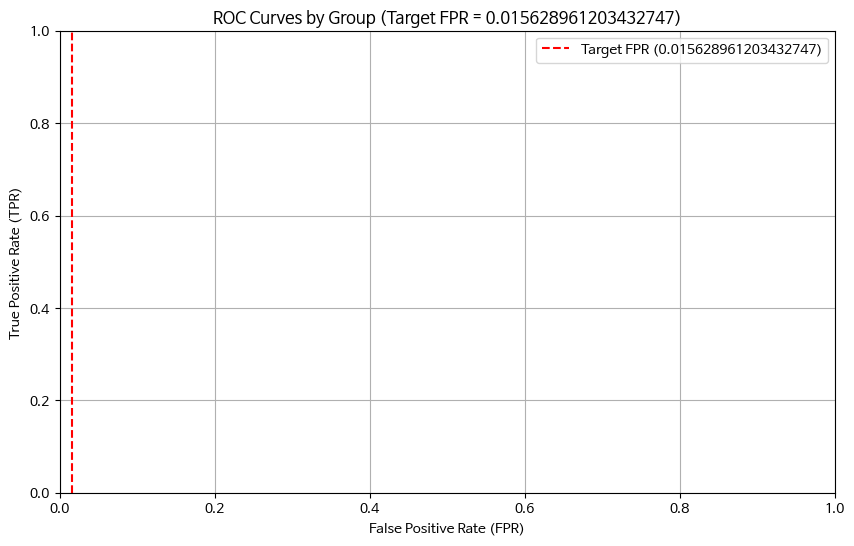

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1624
PR-AUC : 0.1997
Recall    : 0.0948
Precision : 0.5672

       [최종 - 집단별 임계값]       
Group F: 1.0000
Group M: 1.0000

       [최종 - 연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.029823  0.114026  0.986251  0.013749  0.885974
M             0.023491  0.072143  0.985929  0.014071  0.927857

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.006332
tpr               0.041883
tnr               0.000322
fpr               0.000322
fnr               0.041883
dtype: float64

 ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.

 [Step 0] Base Model (보정 전) 학습 결과



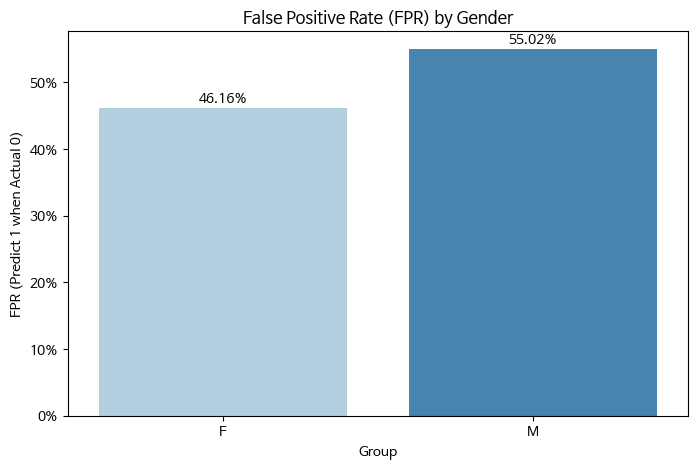

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.510500,51.05%,76.66%,46.16%,24.07%
1,M,0.162200,0.592200,59.22%,80.95%,55.02%,22.17%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



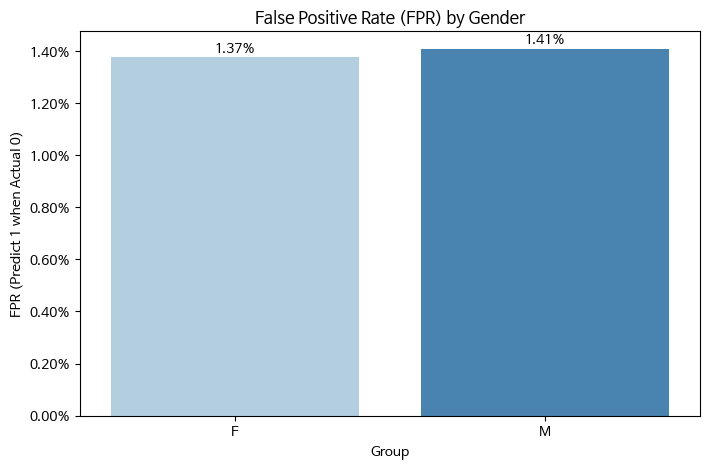

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.029800,2.98%,11.40%,1.37%,61.29%
1,M,0.162200,0.023500,2.35%,7.21%,1.41%,49.82%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



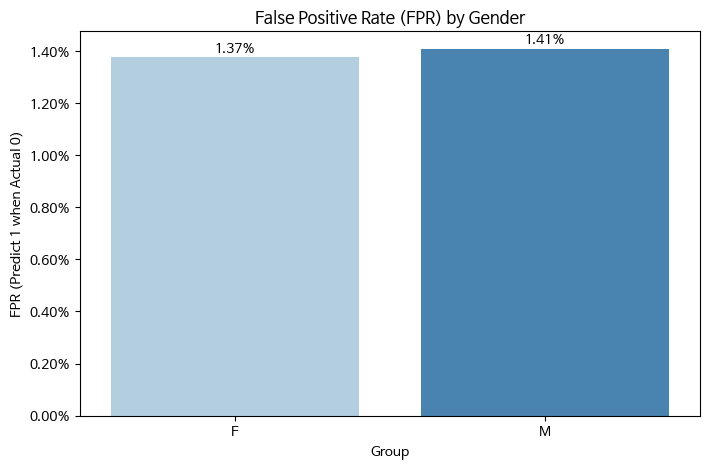

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.029800,2.98%,11.40%,1.37%,61.29%
1,M,0.162200,0.023500,2.35%,7.21%,1.41%,49.82%


In [ ]:
var_name = 'gender'
x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        model, threshold
        )


       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.510464  0.766641  0.538439  0.461561  0.233359
M             0.592226  0.809464  0.449834  0.550166  0.190536
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.081762
tpr               0.042823
tnr               0.088605
fpr               0.088605
fnr               0.042823
dtype: float64
       [최종 모델 전체 성능 결과]        
F1-Score  : 0.2151
PR-AUC : 0.2069
Recall    : 0.1375
Precision : 0.4934

       [집단별 임계값]       
연령대: F       | 추정 임계값: 0.3619
연령대: M       | 추정 임계값: 0.4132

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.046448  0.1

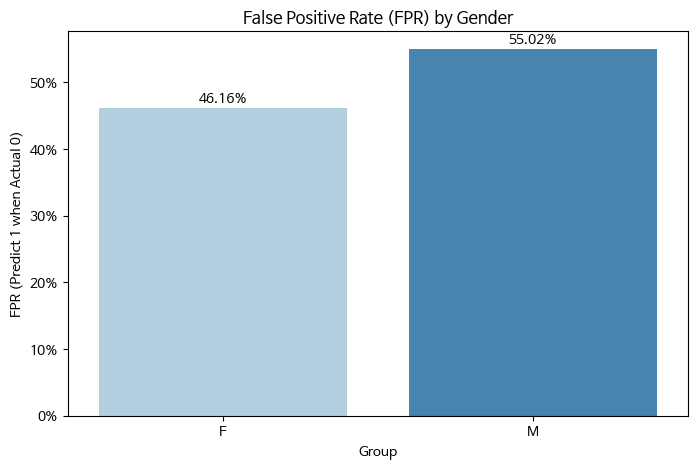

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.510500,51.05%,76.66%,46.16%,24.07%
1,M,0.162200,0.592200,59.22%,80.95%,55.02%,22.17%



 [Step 3] Base Model (보정 전) 학습 결과


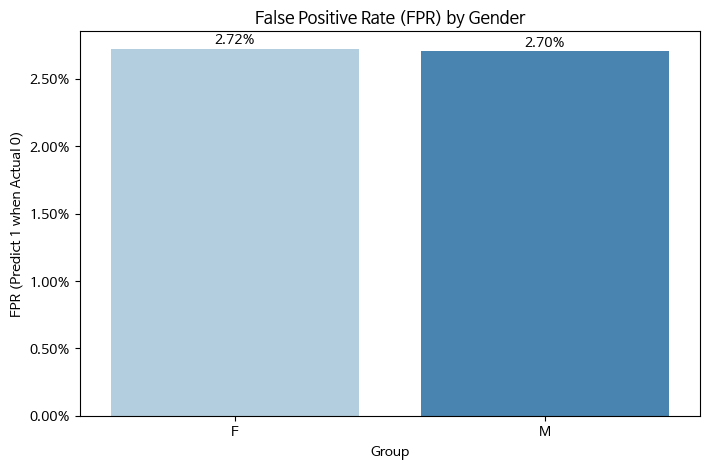

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.046400,4.64%,14.72%,2.72%,50.81%
1,M,0.162200,0.043100,4.31%,12.61%,2.70%,47.45%


In [ ]:
var_name = 'gender'
y_pred_final = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

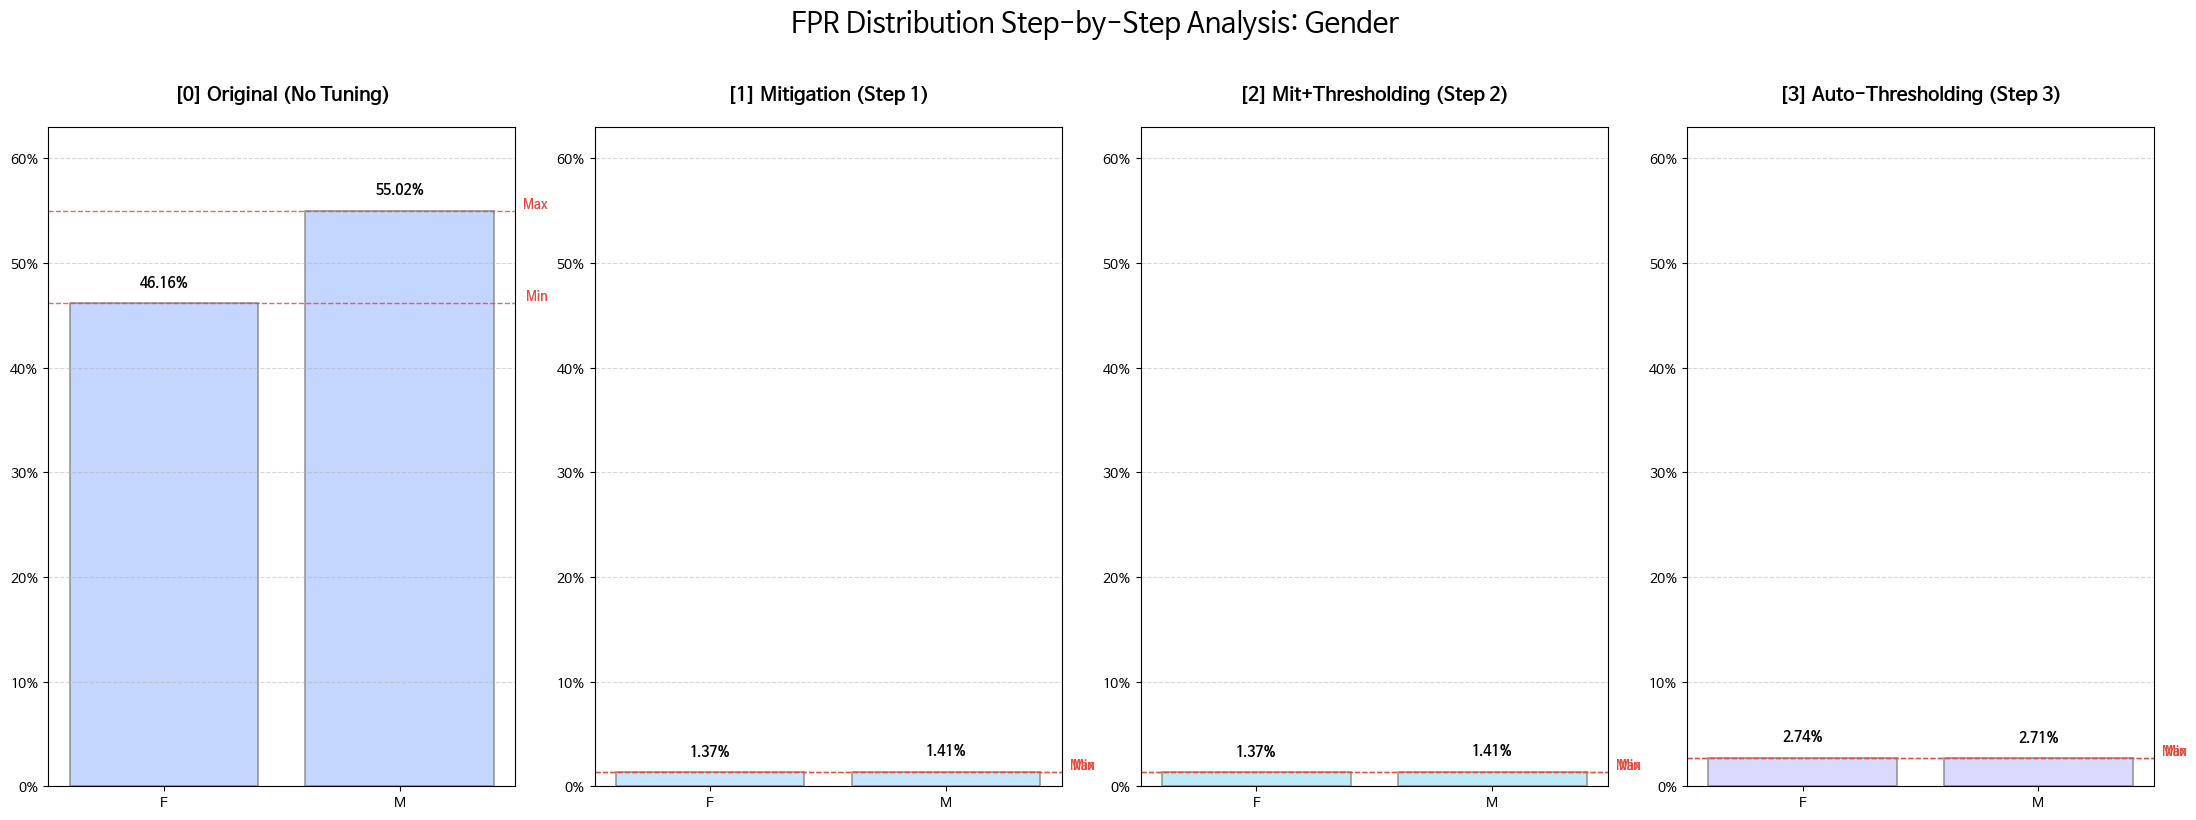

In [ ]:
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

#### 나이

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
      selection_rate       tpr       tnr       fpr       fnr
age                                                         
10s         0.856077  0.938854  0.167291  0.832709  0.061146
20s         0.766165  0.899787  0.269693  0.730307  0.100213
30s         0.713013  0.845509  0.321484  0.678516  0.154491
40s         0.618645  0.783427  0.416516  0.583484  0.216573
50s         0.472911  0.736921  0.567851  0.432149  0.263079
60s         0.274916  0.608187  0.755926  0.244074  0.391813
70s+        0.136577  0.315217  0.882009  0.117991  0.684783
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.719500
tpr               0.623637
tnr               0.714718
fpr               0.714718
fnr               0.623637
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습


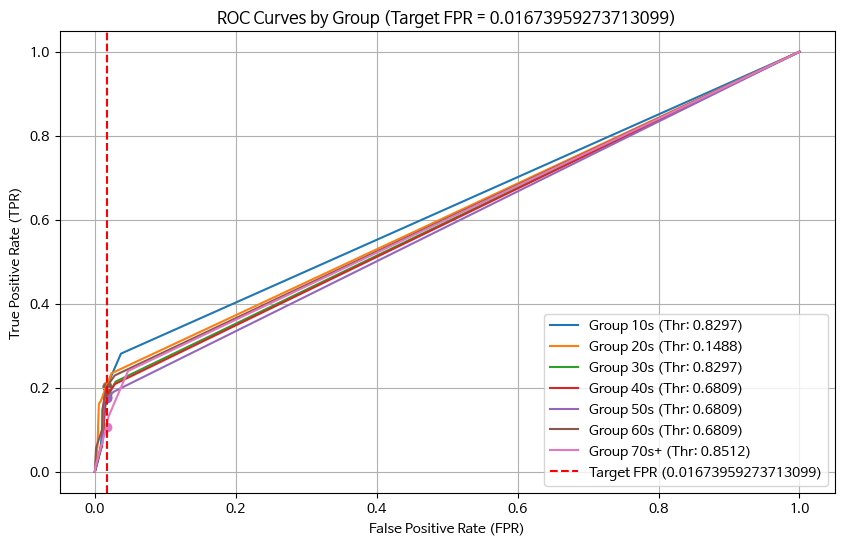

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1878
PR-AUC : 0.2162
Recall    : 0.1164
Precision : 0.4870

       [최종 - 집단별 임계값]       
Group 10s: 0.8297
Group 20s: 0.1488
Group 30s: 0.8297
Group 40s: 0.6809
Group 50s: 0.6809
Group 60s: 0.6809
Group 70s+: 0.8512

       [최종 - 연령대별 공정성 세부 지표]       
      selection_rate       tpr       tnr       fpr       fnr
age                                                         
10s         0.041692  0.107966  0.977017  0.022983  0.892034
20s         0.051278  0.141436  0.972916  0.027084  0.858564
30s         0.036038  0.097006  0.979836  0.020164  0.902994
40s         0.039493  0.104991  0.974483  0.025517  0.895009
50s         0.037285  0.123318  0.975998  0.024002  0.876682
60s         0.035665  0.157895  0.975647  0.024353  0.842105
70s+        0.032778  0.131341  0.977476  0.022524  0.868659

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.018500
tpr               0.060889
tnr               0.006920
fpr               0.006920
fn

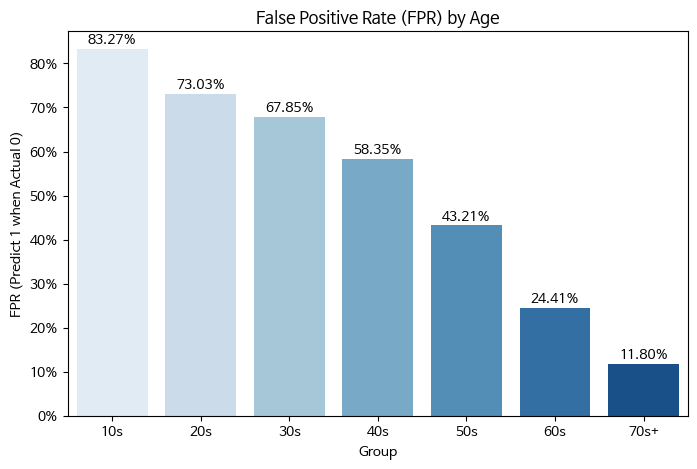

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.856100,85.61%,93.89%,83.27%,24.14%
1,20s,0.211600,0.766200,76.62%,89.98%,73.03%,24.85%
2,30s,0.206600,0.713000,71.30%,84.55%,67.85%,24.50%
3,40s,0.175900,0.618600,61.86%,78.34%,58.35%,22.27%
4,50s,0.133700,0.472900,47.29%,73.69%,43.21%,20.84%
5,60s,0.084700,0.274900,27.49%,60.82%,24.41%,18.74%
6,70s+,0.094200,0.136600,13.66%,31.52%,11.80%,21.75%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



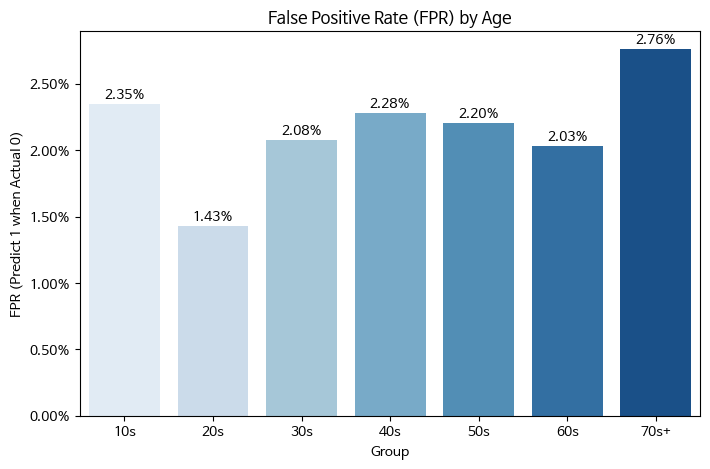

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.041700,4.17%,10.62%,2.35%,56.09%
1,20s,0.211600,0.029900,2.99%,8.81%,1.43%,62.31%
2,30s,0.206600,0.036900,3.69%,9.86%,2.08%,55.26%
3,40s,0.175900,0.036300,3.63%,9.98%,2.28%,48.29%
4,50s,0.133700,0.034700,3.47%,11.66%,2.20%,44.96%
5,60s,0.084700,0.029600,2.96%,12.98%,2.03%,37.12%
6,70s+,0.094200,0.037800,3.78%,13.59%,2.76%,33.86%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



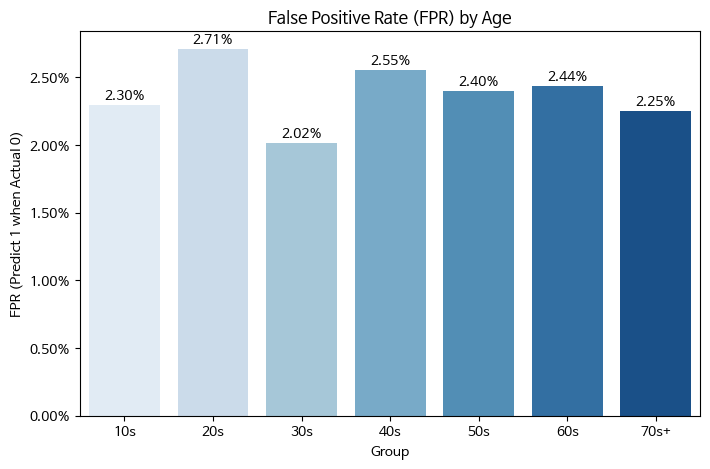

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.041700,4.17%,10.80%,2.30%,57.01%
1,20s,0.211600,0.051300,5.13%,14.14%,2.71%,58.36%
2,30s,0.206600,0.036000,3.60%,9.70%,2.02%,55.61%
3,40s,0.175900,0.039500,3.95%,10.50%,2.55%,46.75%
4,50s,0.133700,0.037300,3.73%,12.33%,2.40%,44.24%
5,60s,0.084700,0.035700,3.57%,15.79%,2.44%,37.50%
6,70s+,0.094200,0.032800,3.28%,13.13%,2.25%,37.76%


In [ ]:
var_name = 'age'
x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        model, threshold
        )


       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
      selection_rate       tpr       tnr       fpr       fnr
age                                                         
10s         0.856077  0.938854  0.167291  0.832709  0.061146
20s         0.766165  0.899787  0.269693  0.730307  0.100213
30s         0.713013  0.845509  0.321484  0.678516  0.154491
40s         0.618645  0.783427  0.416516  0.583484  0.216573
50s         0.472911  0.736921  0.567851  0.432149  0.263079
60s         0.274916  0.608187  0.755926  0.244074  0.391813
70s+        0.136577  0.315217  0.882009  0.117991  0.684783
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.719500
tpr               0.623637
tnr               0.714718
fpr               0.714718
fnr               0.623637
dtype: float64
       [최종 모델 전체 성능 결과]        
F1-Score  : 0.0111
PR-AUC : 0.1621
Recall    :

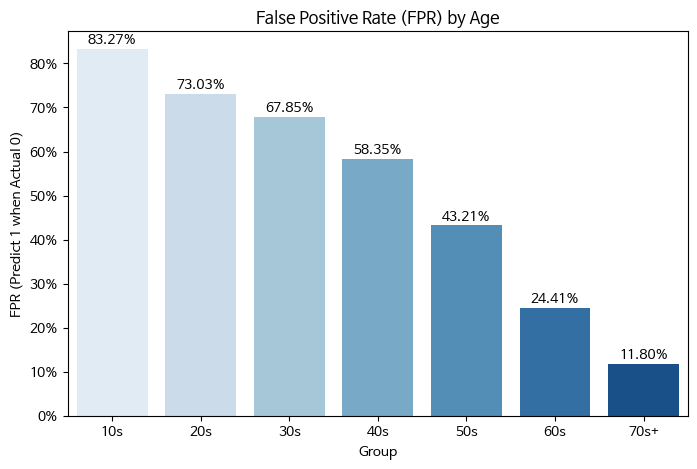

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.856100,85.61%,93.89%,83.27%,24.14%
1,20s,0.211600,0.766200,76.62%,89.98%,73.03%,24.85%
2,30s,0.206600,0.713000,71.30%,84.55%,67.85%,24.50%
3,40s,0.175900,0.618600,61.86%,78.34%,58.35%,22.27%
4,50s,0.133700,0.472900,47.29%,73.69%,43.21%,20.84%
5,60s,0.084700,0.274900,27.49%,60.82%,24.41%,18.74%
6,70s+,0.094200,0.136600,13.66%,31.52%,11.80%,21.75%



 [Step 3] Base Model (보정 전) 학습 결과


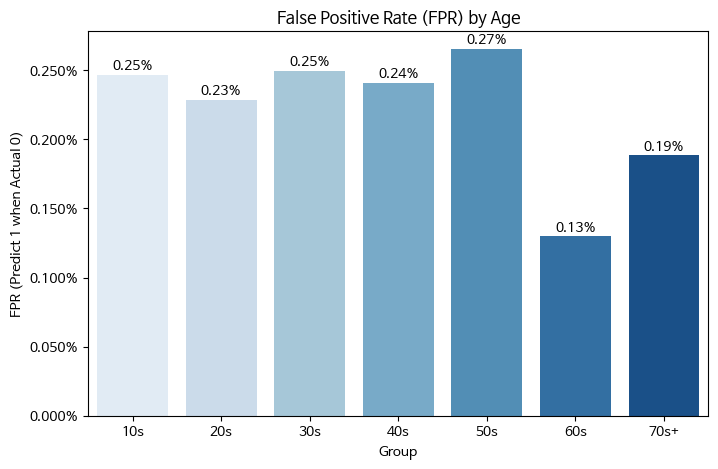

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.003300,0.33%,0.63%,0.25%,41.86%
1,20s,0.211600,0.002400,0.24%,0.28%,0.23%,25.00%
2,30s,0.206600,0.002900,0.29%,0.44%,0.25%,31.43%
3,40s,0.175900,0.003000,0.30%,0.56%,0.24%,33.33%
4,50s,0.133700,0.002700,0.27%,0.30%,0.27%,14.81%
5,60s,0.084700,0.002000,0.20%,0.94%,0.13%,40.00%
6,70s+,0.094200,0.002700,0.27%,1.09%,0.19%,37.50%


In [ ]:
var_name = 'age'
y_pred_final = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

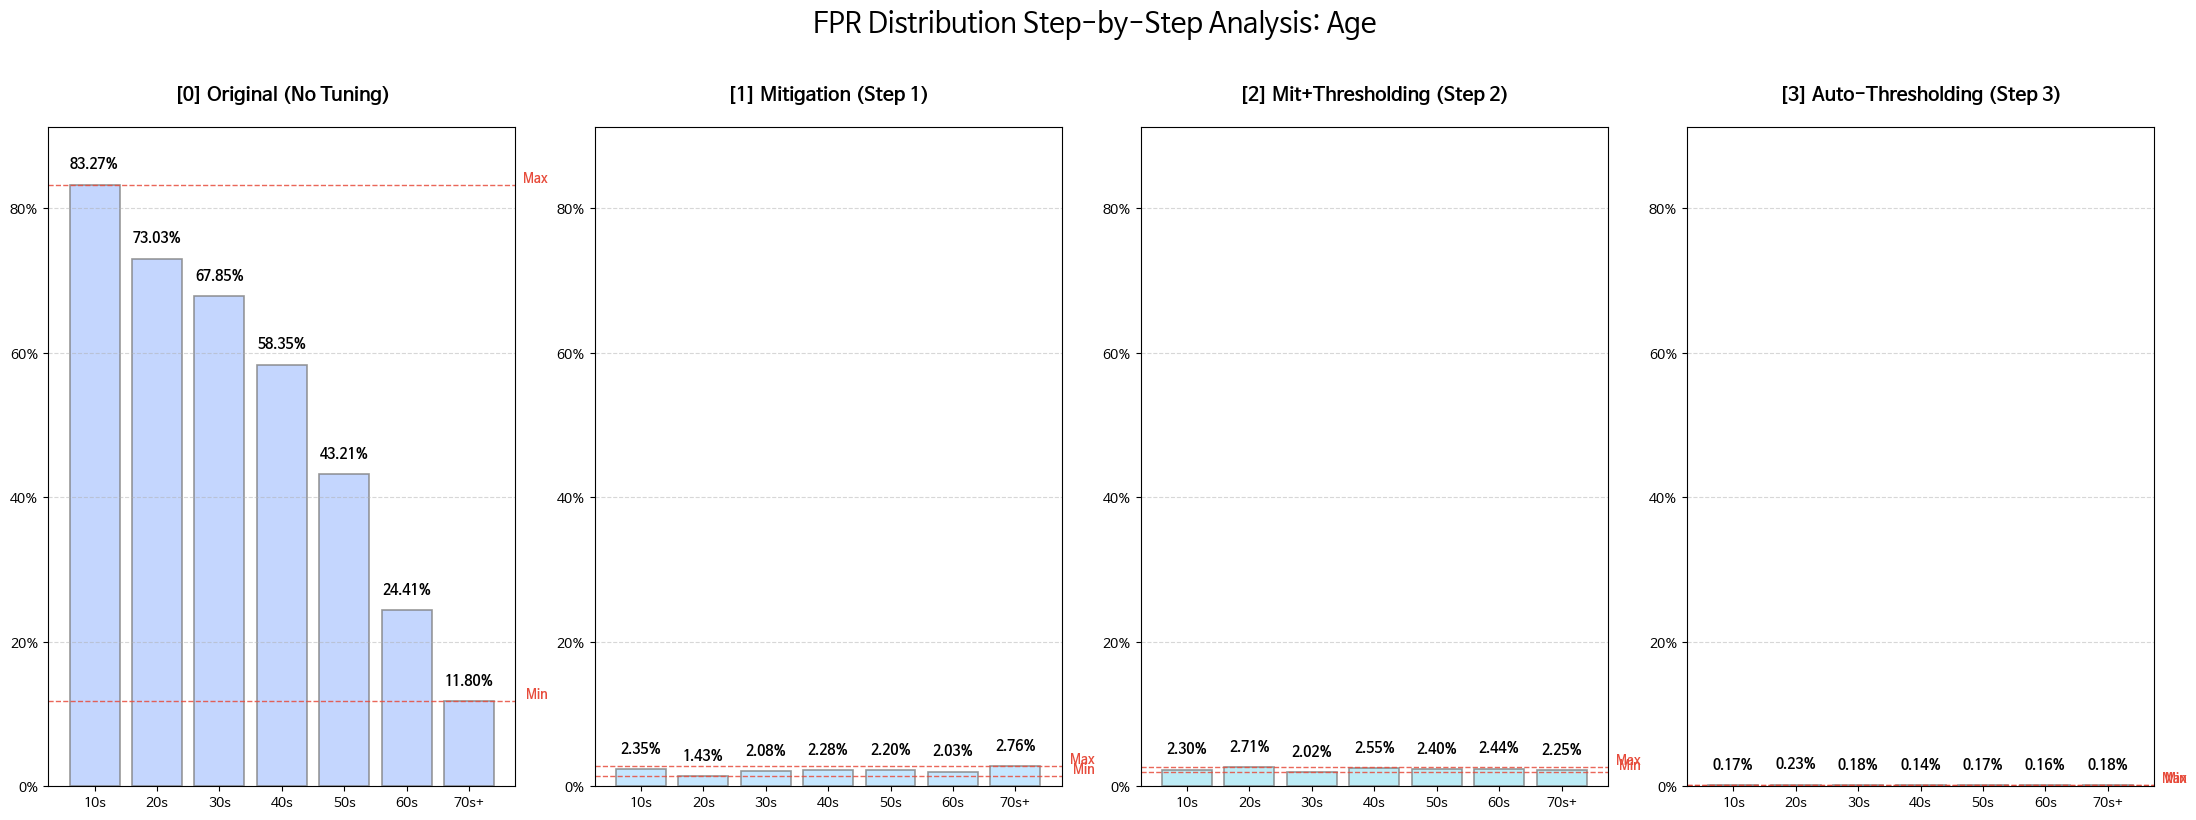

In [ ]:
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

#### 성별 & 나이

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.178410  0.419517  0.843521  0.156479  0.580483
F_장년           0.678801  0.826687  0.361269  0.638731  0.173313
F_중년           0.490026  0.729609  0.553119  0.446881  0.270391
F_청년           0.829606  0.925067  0.197802  0.802198  0.074933
M_고령           0.211059  0.439535  0.813115  0.186885  0.560465
M_장년           0.767869  0.887029  0.261315  0.738685  0.112971
M_중년           0.595854  0.796968  0.440583  0.559417  0.203032
M_청년           0.844681  0.935718  0.180116  0.819884  0.064282
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.666271
tpr               0.516201
tnr               0.663406
fpr               0.

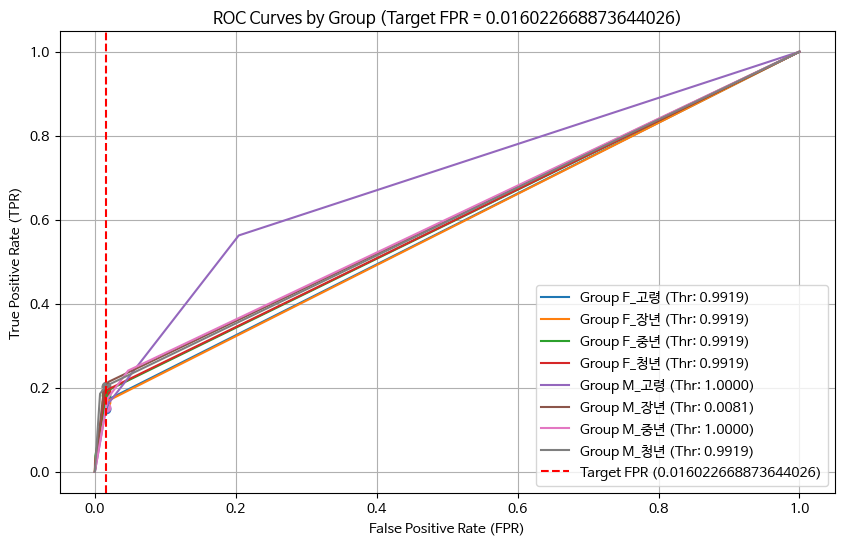

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1894
PR-AUC : 0.2031
Recall    : 0.1182
Precision : 0.4765

       [최종 - 집단별 임계값]       
Group F_고령: 0.9919
Group F_장년: 0.9919
Group F_중년: 0.9919
Group F_청년: 0.9919
Group M_고령: 1.0000
Group M_장년: 0.0081
Group M_중년: 1.0000
Group M_청년: 0.9919

       [최종 - 연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.041184  0.157948  0.969436  0.030564  0.842052
F_장년           0.035204  0.113497  0.986009  0.013991  0.886503
F_중년           0.036317  0.124022  0.979477  0.020523  0.875978
F_청년           0.043290  0.115364  0.977403  0.022597  0.884636
M_고령           0.036938  0.163953  0.976501  0.023499  0.836047
M_장년           0.055152  0.124128  0.961742  0.038258  0.875872
M_중년           0.039939  0.100198  0.970978  0.029022  0.899802
M_청년           0.035300  0.086641  0.978685  0.021315  0.913359

       [최종 - 집단 간 최대 격차 (Max Gap)] 

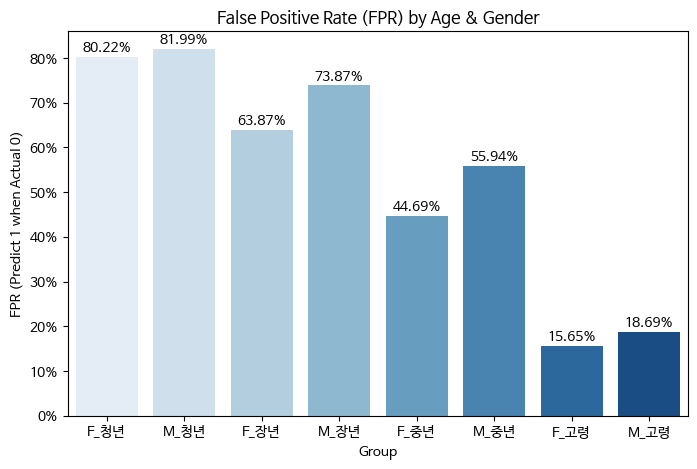

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.829600,82.96%,92.51%,80.22%,24.87%
1,M_청년,0.214100,0.844700,84.47%,93.57%,81.99%,23.71%
2,F_장년,0.213200,0.678800,67.88%,82.67%,63.87%,25.96%
3,M_장년,0.196700,0.767900,76.79%,88.70%,73.87%,22.73%
4,F_중년,0.152600,0.490000,49.00%,72.96%,44.69%,22.72%
5,M_중년,0.153400,0.595900,59.59%,79.70%,55.94%,20.52%
6,F_고령,0.083400,0.178400,17.84%,41.95%,15.65%,19.61%
7,M_고령,0.095700,0.211100,21.11%,43.95%,18.69%,19.93%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



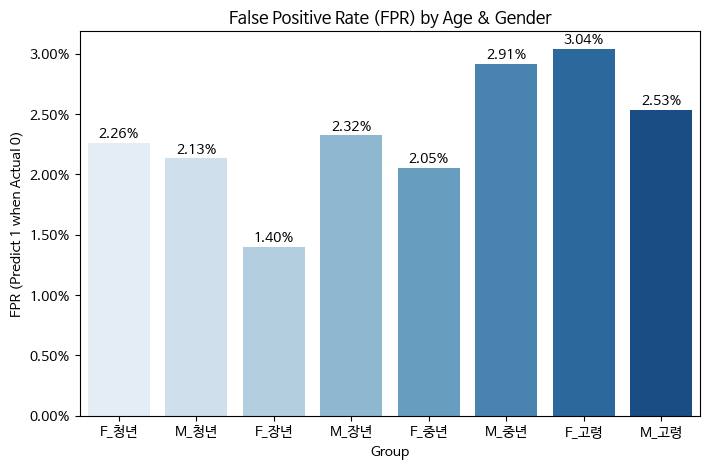

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.043200,4.32%,11.48%,2.26%,59.33%
1,M_청년,0.214100,0.035300,3.53%,8.66%,2.13%,52.54%
2,F_장년,0.213200,0.034900,3.49%,11.20%,1.40%,68.44%
3,M_장년,0.196700,0.034700,3.47%,8.16%,2.32%,46.25%
4,F_중년,0.152600,0.036200,3.62%,12.35%,2.05%,52.00%
5,M_중년,0.153400,0.040100,4.01%,10.09%,2.91%,38.54%
6,F_고령,0.083400,0.041000,4.10%,15.79%,3.04%,32.11%
7,M_고령,0.095700,0.038700,3.87%,16.51%,2.53%,40.80%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



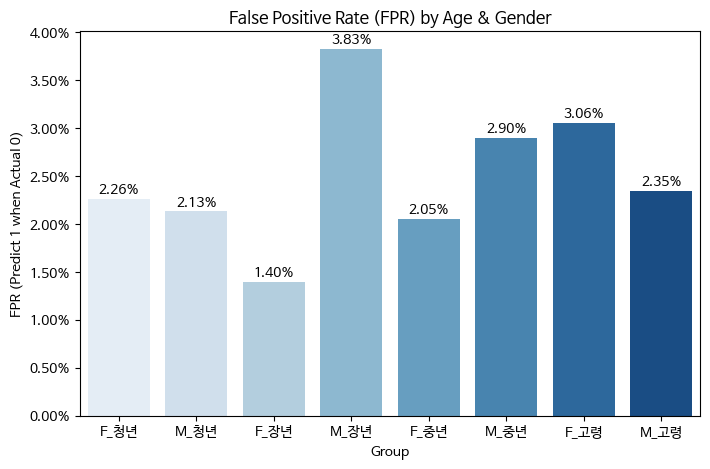

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.043300,4.33%,11.54%,2.26%,59.44%
1,M_청년,0.214100,0.035300,3.53%,8.66%,2.13%,52.54%
2,F_장년,0.213200,0.035200,3.52%,11.35%,1.40%,68.73%
3,M_장년,0.196700,0.055200,5.52%,12.41%,3.83%,44.28%
4,F_중년,0.152600,0.036300,3.63%,12.40%,2.05%,52.11%
5,M_중년,0.153400,0.039900,3.99%,10.02%,2.90%,38.48%
6,F_고령,0.083400,0.041200,4.12%,15.79%,3.06%,31.98%
7,M_고령,0.095700,0.036900,3.69%,16.40%,2.35%,42.47%


In [ ]:
var_name = 'age_gender'
x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        model, threshold
        )


       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.178410  0.419517  0.843521  0.156479  0.580483
F_장년           0.678801  0.826687  0.361269  0.638731  0.173313
F_중년           0.490026  0.729609  0.553119  0.446881  0.270391
F_청년           0.829606  0.925067  0.197802  0.802198  0.074933
M_고령           0.211059  0.439535  0.813115  0.186885  0.560465
M_장년           0.767869  0.887029  0.261315  0.738685  0.112971
M_중년           0.595854  0.796968  0.440583  0.559417  0.203032
M_청년           0.844681  0.935718  0.180116  0.819884  0.064282
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.666271
tpr               0.516201
tnr               0.663406
fpr               0.663406
fnr               0.516201
dt

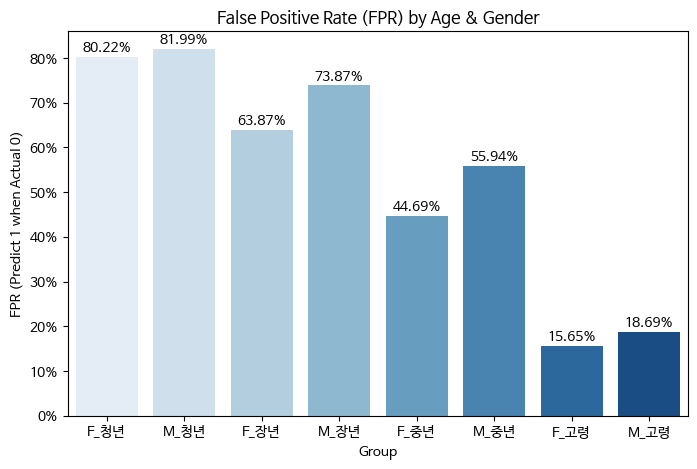

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.829600,82.96%,92.51%,80.22%,24.87%
1,M_청년,0.214100,0.844700,84.47%,93.57%,81.99%,23.71%
2,F_장년,0.213200,0.678800,67.88%,82.67%,63.87%,25.96%
3,M_장년,0.196700,0.767900,76.79%,88.70%,73.87%,22.73%
4,F_중년,0.152600,0.490000,49.00%,72.96%,44.69%,22.72%
5,M_중년,0.153400,0.595900,59.59%,79.70%,55.94%,20.52%
6,F_고령,0.083400,0.178400,17.84%,41.95%,15.65%,19.61%
7,M_고령,0.095700,0.211100,21.11%,43.95%,18.69%,19.93%



 [Step 3] Base Model (보정 전) 학습 결과


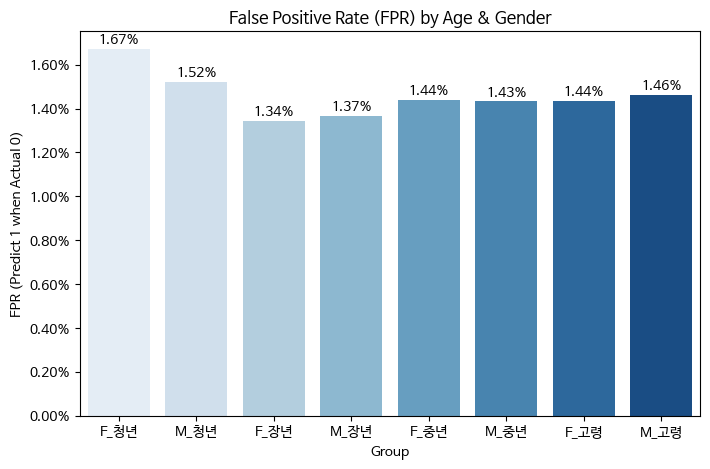

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.029700,2.97%,7.49%,1.67%,56.28%
1,M_청년,0.214100,0.023900,2.39%,5.59%,1.52%,50.00%
2,F_장년,0.213200,0.029100,2.91%,8.69%,1.34%,63.67%
3,M_장년,0.196700,0.022900,2.29%,6.07%,1.37%,52.10%
4,F_중년,0.152600,0.024600,2.46%,8.16%,1.44%,50.52%
5,M_중년,0.153400,0.021400,2.14%,6.06%,1.43%,43.40%
6,F_고령,0.083400,0.018600,1.86%,6.54%,1.44%,29.28%
7,M_고령,0.095700,0.020700,2.07%,7.79%,1.46%,36.02%


In [ ]:
var_name = 'age_gender'
y_pred_final = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

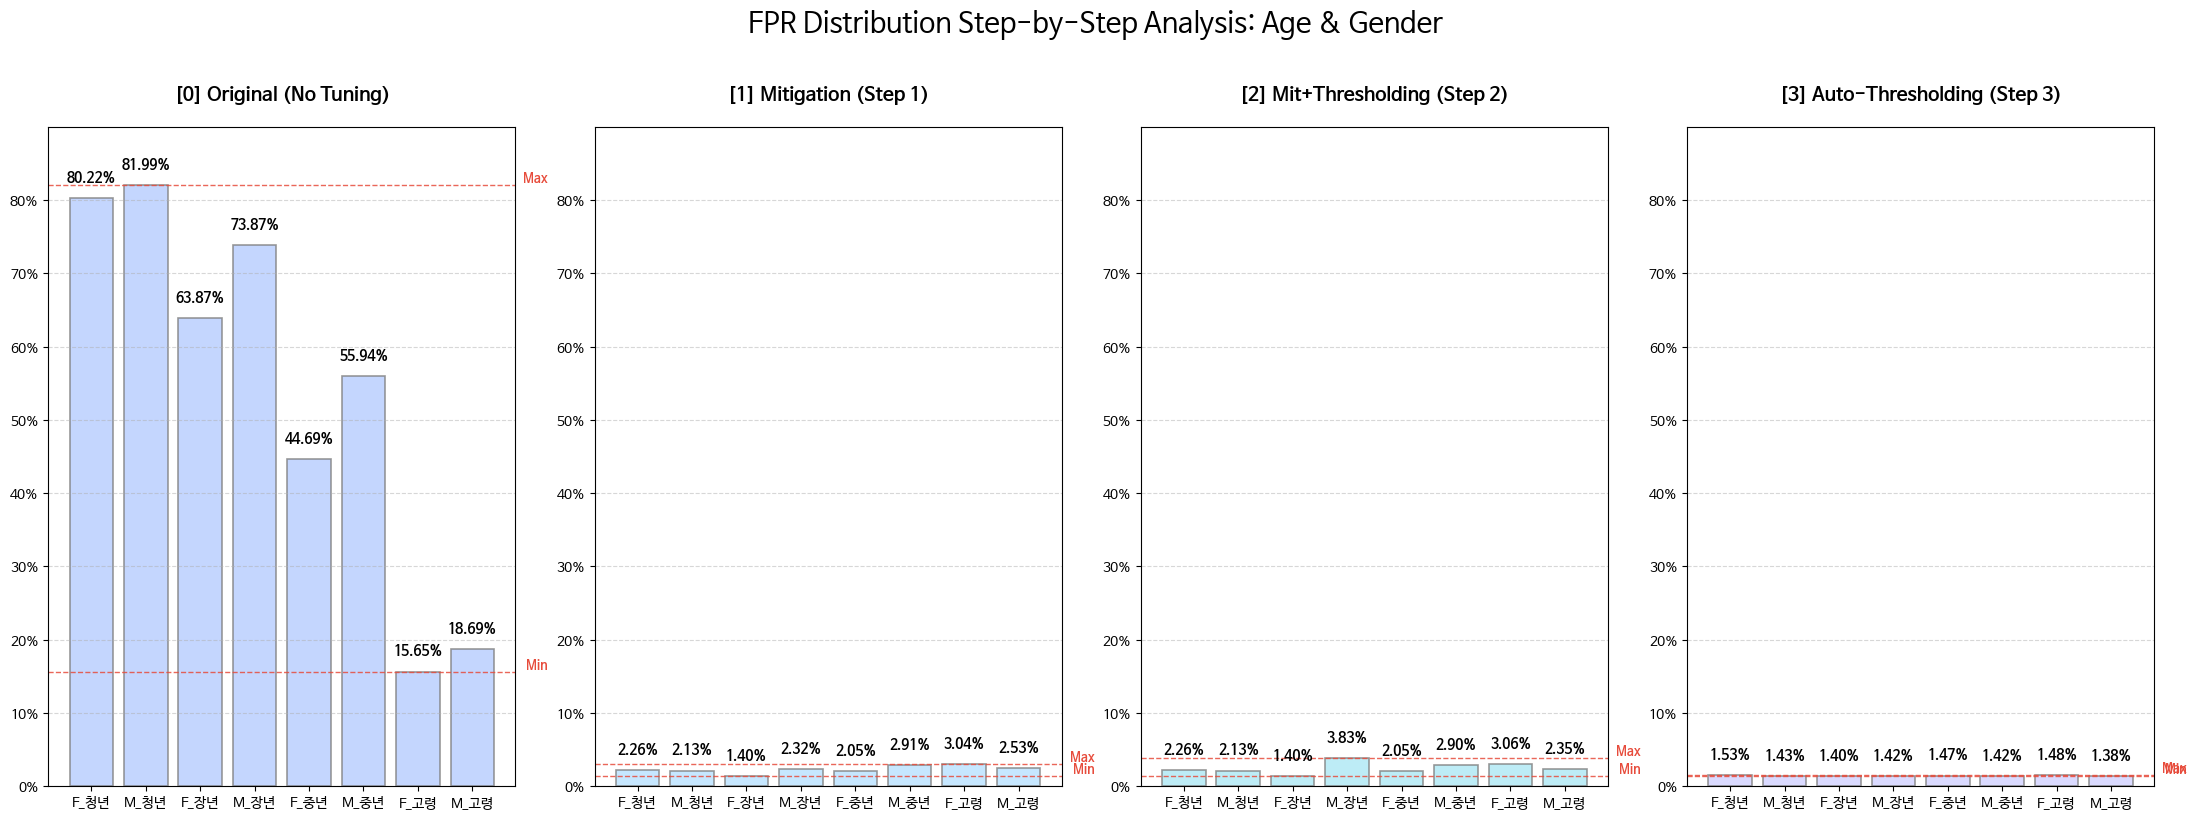

In [ ]:
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

#### 지역

##### `C_H`



 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_H_num                                                        
H1             0.545670  0.714286  0.480164  0.519836  0.285714
H2             0.664839  0.848138  0.375997  0.624003  0.151862
H3             0.637875  0.828526  0.408182  0.591818  0.171474
H4             0.683100  0.859309  0.358566  0.641434  0.140691
H5             0.652411  0.849379  0.396927  0.603073  0.150621
H6             0.469198  0.730921  0.574382  0.425618  0.269079
Unknown        0.578788  0.830769  0.453171  0.546829  0.169231
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.213902
tpr               0.145023
tnr               0.215817
fpr               0.215817
fnr               0.145023
dtype: float64

 [Step 2] Fair

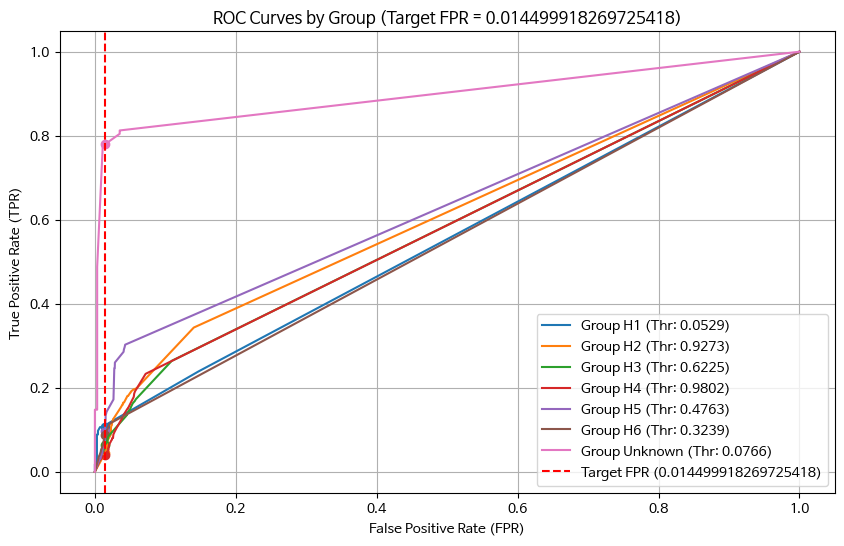

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1377
PR-AUC : 0.2310
Recall    : 0.0785
Precision : 0.5626

       [최종 - 집단별 임계값]       
Group H1: 0.0529
Group H2: 0.9273
Group H3: 0.6225
Group H4: 0.9802
Group H5: 0.4763
Group H6: 0.3239
Group Unknown: 0.0766

       [최종 - 연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_H_num                                                        
H1             0.016607  0.071429  0.991792  0.008208  0.928571
H2             0.014748  0.038682  0.990584  0.009416  0.961318
H3             0.021411  0.060897  0.988128  0.011872  0.939103
H4             0.023200  0.074979  0.989044  0.010956  0.925021
H5             0.025039  0.087733  0.990665  0.009335  0.912267
H6             0.023783  0.091941  0.987566  0.012434  0.908059
Unknown        0.021645  0.076923  0.985366  0.014634  0.923077

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.010291
tpr               0.053259
tnr               0.006426
fpr  

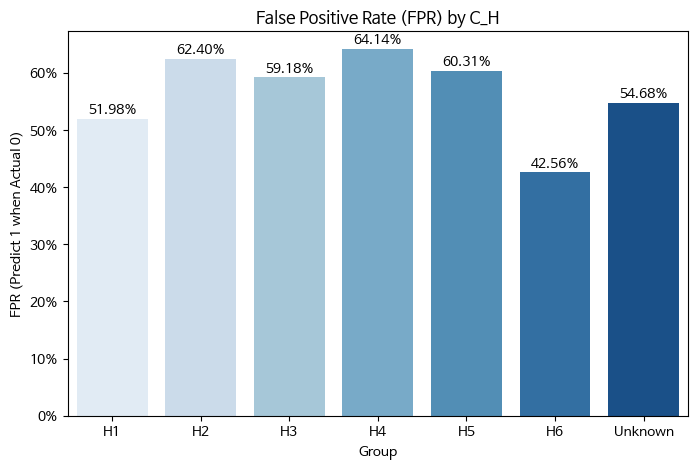

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.545700,54.57%,71.43%,51.98%,17.39%
1,H2,0.182200,0.664800,66.48%,84.81%,62.40%,23.24%
2,H3,0.194600,0.637900,63.79%,82.85%,59.18%,25.27%
3,H4,0.191200,0.683100,68.31%,85.93%,64.14%,24.06%
4,H5,0.200300,0.652400,65.24%,84.94%,60.31%,26.08%
5,H6,0.142700,0.469200,46.92%,73.09%,42.56%,22.24%
6,Unknown,0.112600,0.578800,57.88%,83.08%,54.68%,16.16%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



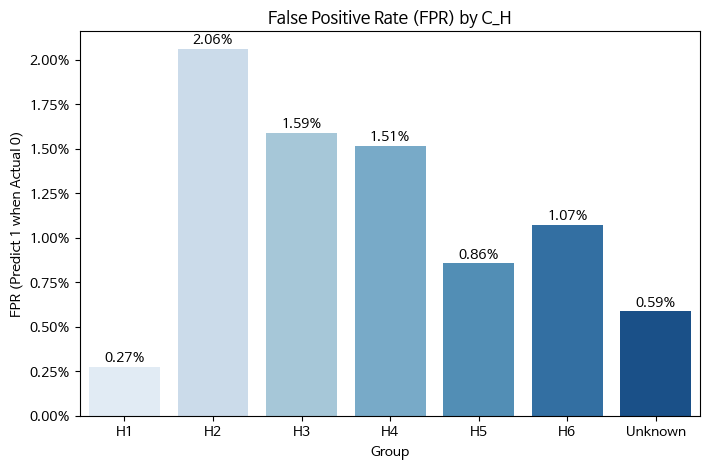

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.008300,0.83%,4.46%,0.27%,71.43%
1,H2,0.182200,0.032000,3.20%,8.31%,2.06%,47.35%
2,H3,0.194600,0.026100,2.61%,6.84%,1.59%,51.00%
3,H4,0.191200,0.033700,3.37%,11.20%,1.51%,63.64%
4,H5,0.200300,0.022700,2.27%,7.92%,0.86%,69.86%
5,H6,0.142700,0.020300,2.03%,7.81%,1.07%,54.85%
6,Unknown,0.112600,0.006100,0.61%,0.77%,0.59%,14.29%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



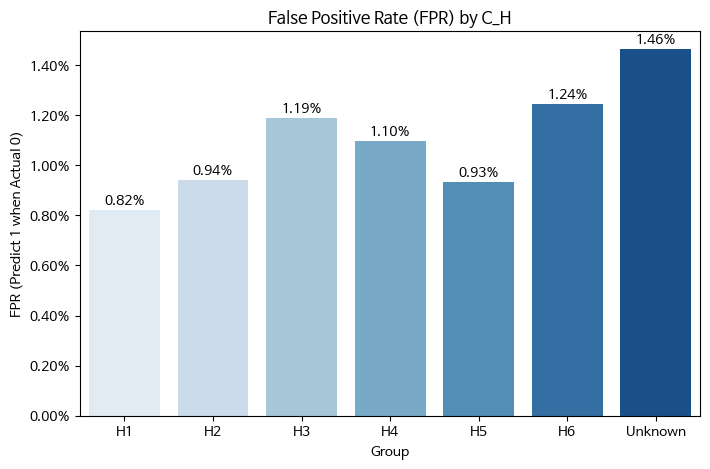

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.016600,1.66%,7.14%,0.82%,57.14%
1,H2,0.182200,0.014700,1.47%,3.87%,0.94%,47.79%
2,H3,0.194600,0.021400,2.14%,6.09%,1.19%,55.34%
3,H4,0.191200,0.023200,2.32%,7.50%,1.10%,61.81%
4,H5,0.200300,0.025000,2.50%,8.77%,0.93%,70.19%
5,H6,0.142700,0.023800,2.38%,9.19%,1.24%,55.18%
6,Unknown,0.112600,0.021600,2.16%,7.69%,1.46%,40.00%


In [ ]:
var_name = 'c_h'
x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        model, threshold
        )


       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_H_num                                                        
H1             0.545670  0.714286  0.480164  0.519836  0.285714
H2             0.664839  0.848138  0.375997  0.624003  0.151862
H3             0.637875  0.828526  0.408182  0.591818  0.171474
H4             0.683100  0.859309  0.358566  0.641434  0.140691
H5             0.652411  0.849379  0.396927  0.603073  0.150621
H6             0.469198  0.730921  0.574382  0.425618  0.269079
Unknown        0.578788  0.830769  0.453171  0.546829  0.169231
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.213902
tpr               0.145023
tnr               0.215817
fpr               0.215817
fnr               0.145023
dtype: float64
       [최종 모델 전체 성능 결과]        
F1-Score  : 0.0076


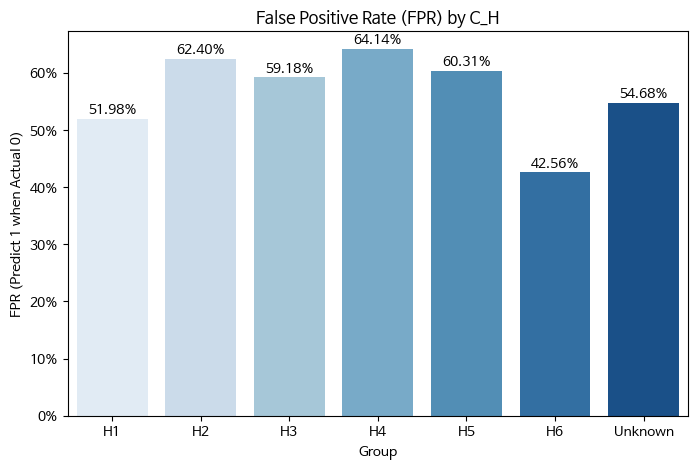

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.545700,54.57%,71.43%,51.98%,17.39%
1,H2,0.182200,0.664800,66.48%,84.81%,62.40%,23.24%
2,H3,0.194600,0.637900,63.79%,82.85%,59.18%,25.27%
3,H4,0.191200,0.683100,68.31%,85.93%,64.14%,24.06%
4,H5,0.200300,0.652400,65.24%,84.94%,60.31%,26.08%
5,H6,0.142700,0.469200,46.92%,73.09%,42.56%,22.24%
6,Unknown,0.112600,0.578800,57.88%,83.08%,54.68%,16.16%



 [Step 3] Base Model (보정 전) 학습 결과


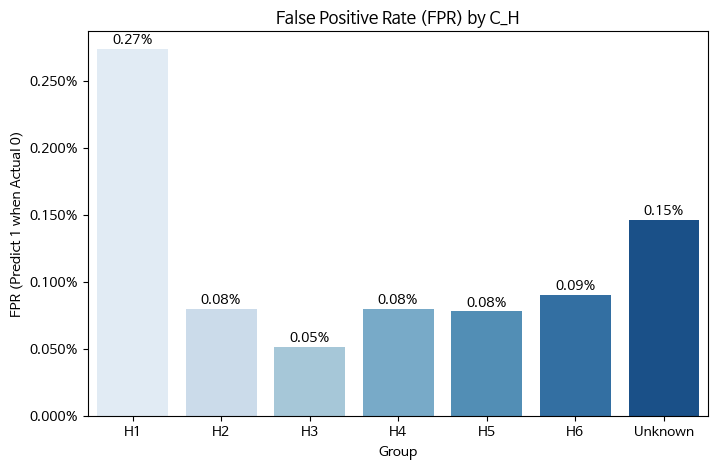

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.003600,0.36%,0.89%,0.27%,33.33%
1,H2,0.182200,0.001200,0.12%,0.29%,0.08%,44.44%
2,H3,0.194600,0.000800,0.08%,0.21%,0.05%,50.00%
3,H4,0.191200,0.001400,0.14%,0.42%,0.08%,55.56%
4,H5,0.200300,0.001900,0.19%,0.62%,0.08%,66.67%
5,H6,0.142700,0.001300,0.13%,0.39%,0.09%,42.11%
6,Unknown,0.112600,0.001700,0.17%,0.38%,0.15%,25.00%


In [ ]:
var_name = 'c_h'
y_pred_final = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

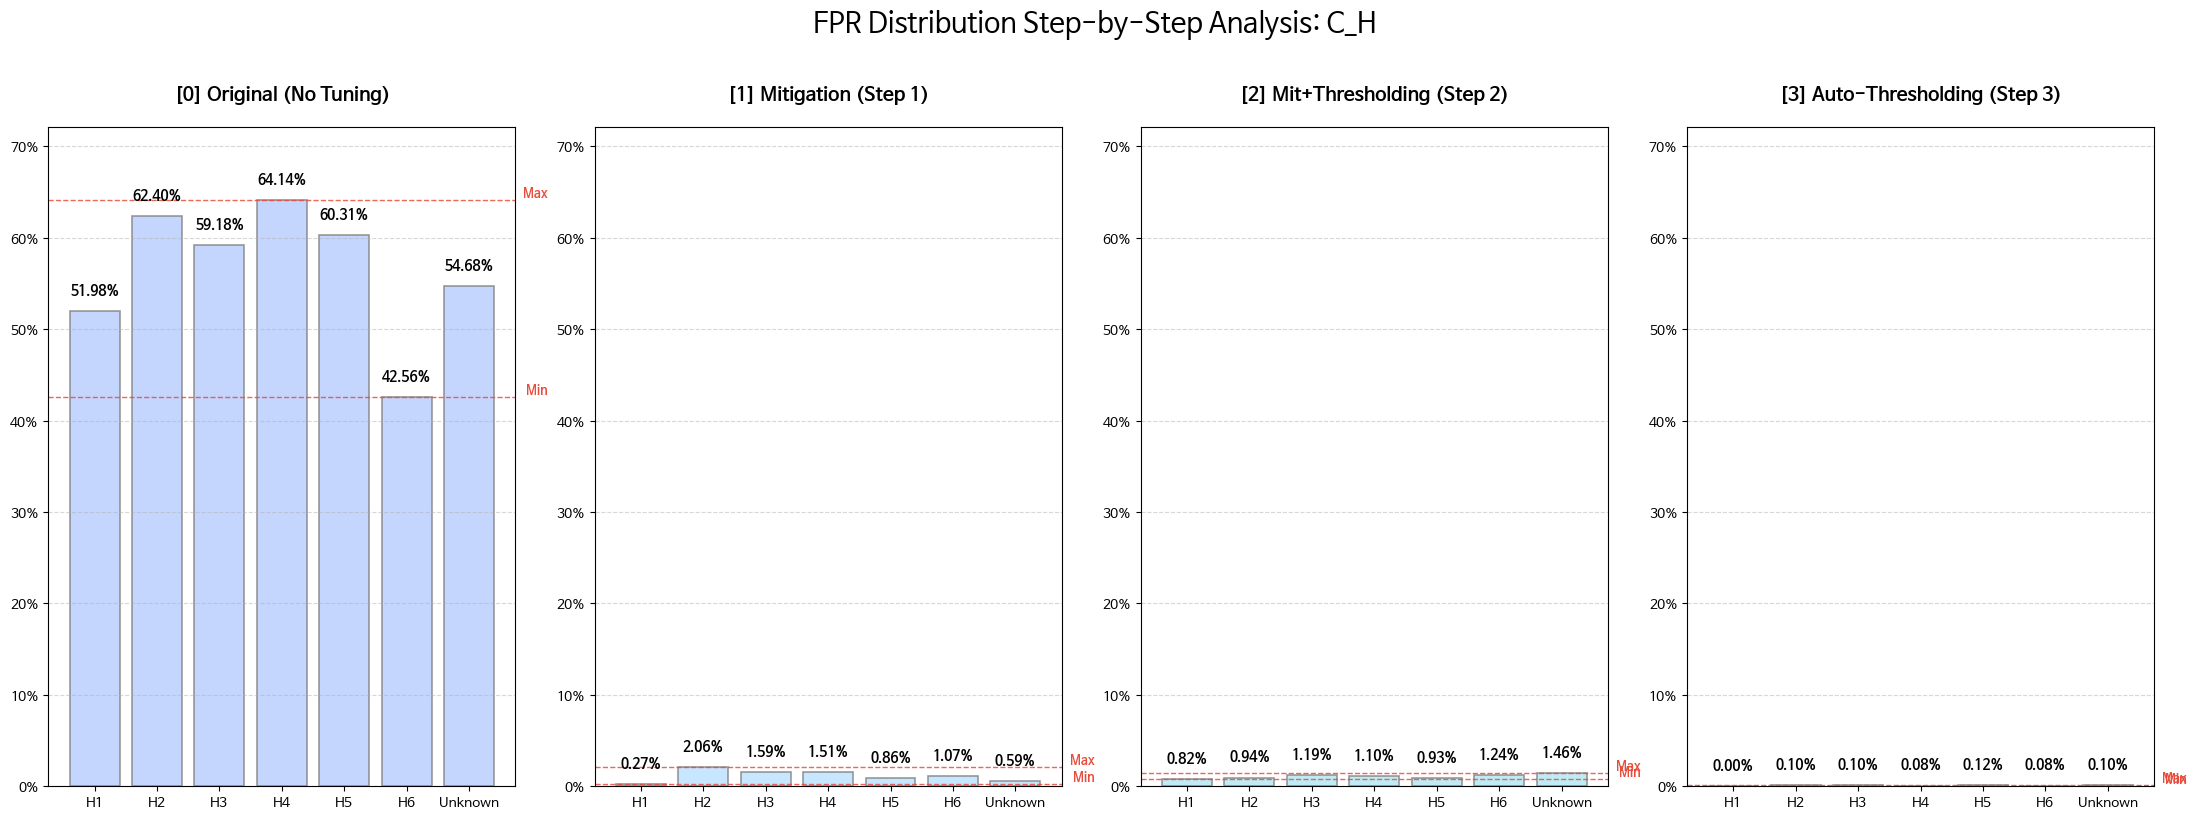

In [ ]:
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

##### `C_GI`

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_GI                                                           
GI_1           0.708445  0.898219  0.342428  0.657572  0.101781
GI_2           0.741236  0.903182  0.307740  0.692260  0.096818
GI_3           0.715954  0.894783  0.331510  0.668490  0.105217
GI_4           0.483585  0.724093  0.556778  0.443222  0.275907
Unknown        0.572879  0.827195  0.460370  0.539630  0.172805
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.257650
tpr               0.179089
tnr               0.249038
fpr               0.249038
fnr               0.179089
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습

⚖️ Fairlearn 재학습 중...
       [Fairlearn 모델 1차 학습 성능 결과]        
F1-Score: 0.1608
PR-AUC: 0.2165
Reca

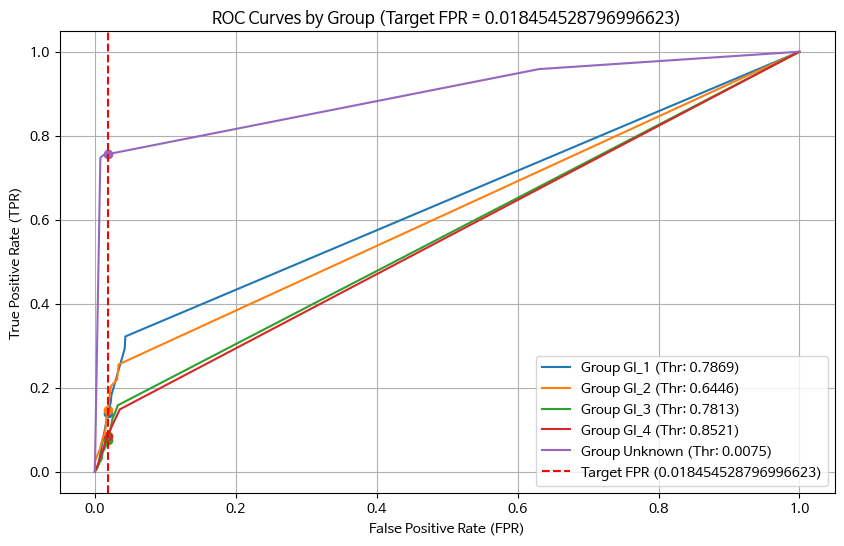

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1466
PR-AUC : 0.2165
Recall    : 0.0848
Precision : 0.5414

       [최종 - 집단별 임계값]       
Group GI_1: 0.7869
Group GI_2: 0.6446
Group GI_3: 0.7813
Group GI_4: 0.8521
Group Unknown: 0.0075

       [최종 - 연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_GI                                                           
GI_1           0.023131  0.061069  0.987040  0.012960  0.938931
GI_2           0.041817  0.128639  0.984439  0.015561  0.871361
GI_3           0.030069  0.087242  0.985106  0.014894  0.912758
GI_4           0.022366  0.076843  0.986777  0.013223  0.923157
Unknown        0.025221  0.084986  0.982593  0.017407  0.915014

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.019451
tpr               0.067570
tnr               0.004447
fpr               0.004447
fnr               0.067570
dtype: float64

 ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.

 [Step 0] Base Model (보정 전) 학습 결과



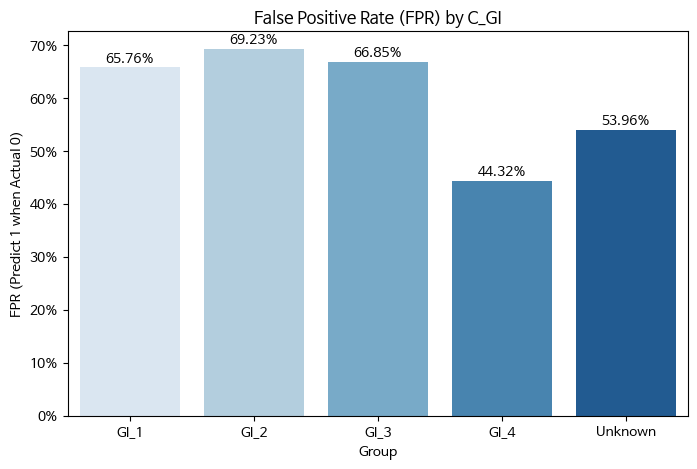

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.708400,70.84%,89.82%,65.76%,26.80%
1,GI_2,0.232200,0.741200,74.12%,90.32%,69.23%,28.29%
2,GI_3,0.209700,0.716000,71.60%,89.48%,66.85%,26.21%
3,GI_4,0.143700,0.483600,48.36%,72.41%,44.32%,21.52%
4,Unknown,0.115600,0.572900,57.29%,82.72%,53.96%,16.70%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



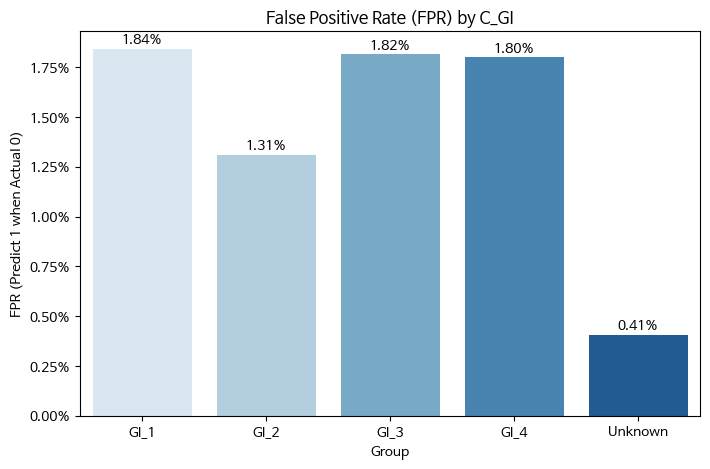

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.029000,2.90%,6.87%,1.84%,50.00%
1,GI_2,0.232200,0.033000,3.30%,9.88%,1.31%,69.52%
2,GI_3,0.209700,0.039400,3.94%,11.92%,1.82%,63.55%
3,GI_4,0.143700,0.028700,2.87%,9.26%,1.80%,46.32%
4,Unknown,0.115600,0.004900,0.49%,1.13%,0.41%,26.67%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



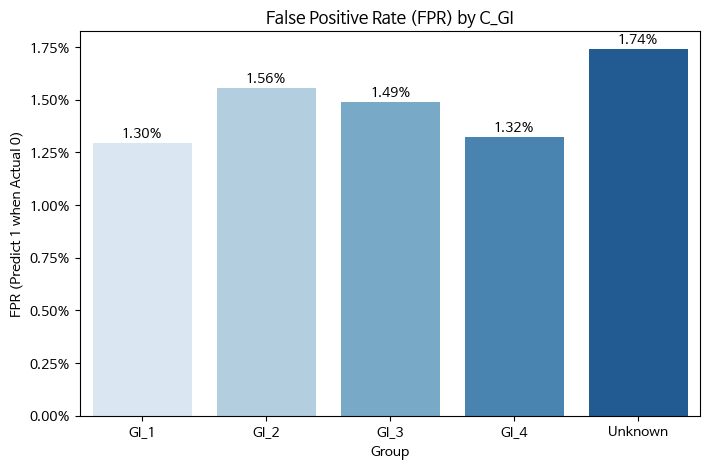

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.023100,2.31%,6.11%,1.30%,55.81%
1,GI_2,0.232200,0.041800,4.18%,12.86%,1.56%,71.43%
2,GI_3,0.209700,0.030100,3.01%,8.72%,1.49%,60.86%
3,GI_4,0.143700,0.022400,2.24%,7.68%,1.32%,49.37%
4,Unknown,0.115600,0.025200,2.52%,8.50%,1.74%,38.96%


In [ ]:
var_name = 'c_gi'
x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        model, threshold
        )


       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_GI                                                           
GI_1           0.708445  0.898219  0.342428  0.657572  0.101781
GI_2           0.741236  0.903182  0.307740  0.692260  0.096818
GI_3           0.715954  0.894783  0.331510  0.668490  0.105217
GI_4           0.483585  0.724093  0.556778  0.443222  0.275907
Unknown        0.572879  0.827195  0.460370  0.539630  0.172805
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.257650
tpr               0.179089
tnr               0.249038
fpr               0.249038
fnr               0.179089
dtype: float64
       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1194
PR-AUC : 0.1843
Recall    : 0.0677
Precision : 0.5030

       [집단별 임계값]       
연령대: GI_1    | 추정 임계값: 0.3308
연령대: GI_2    | 추정 임

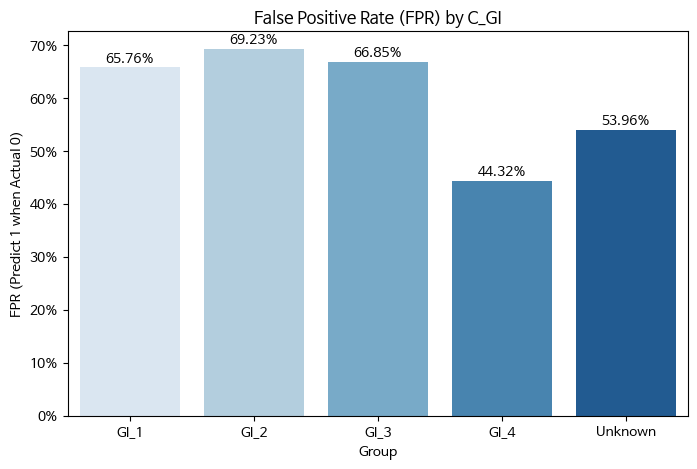

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.708400,70.84%,89.82%,65.76%,26.80%
1,GI_2,0.232200,0.741200,74.12%,90.32%,69.23%,28.29%
2,GI_3,0.209700,0.716000,71.60%,89.48%,66.85%,26.21%
3,GI_4,0.143700,0.483600,48.36%,72.41%,44.32%,21.52%
4,Unknown,0.115600,0.572900,57.29%,82.72%,53.96%,16.70%



 [Step 3] Base Model (보정 전) 학습 결과


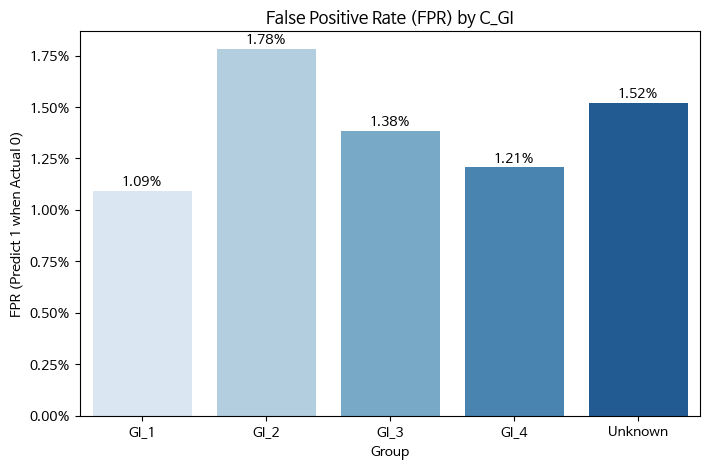

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.015600,1.56%,3.31%,1.09%,44.83%
1,GI_2,0.232200,0.030000,3.00%,7.04%,1.78%,54.45%
2,GI_3,0.209700,0.026600,2.66%,7.45%,1.38%,58.82%
3,GI_4,0.143700,0.020400,2.04%,6.98%,1.21%,49.27%
4,Unknown,0.115600,0.014100,1.41%,0.57%,1.52%,4.65%


In [ ]:
var_name = 'c_gi'
y_pred_final = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

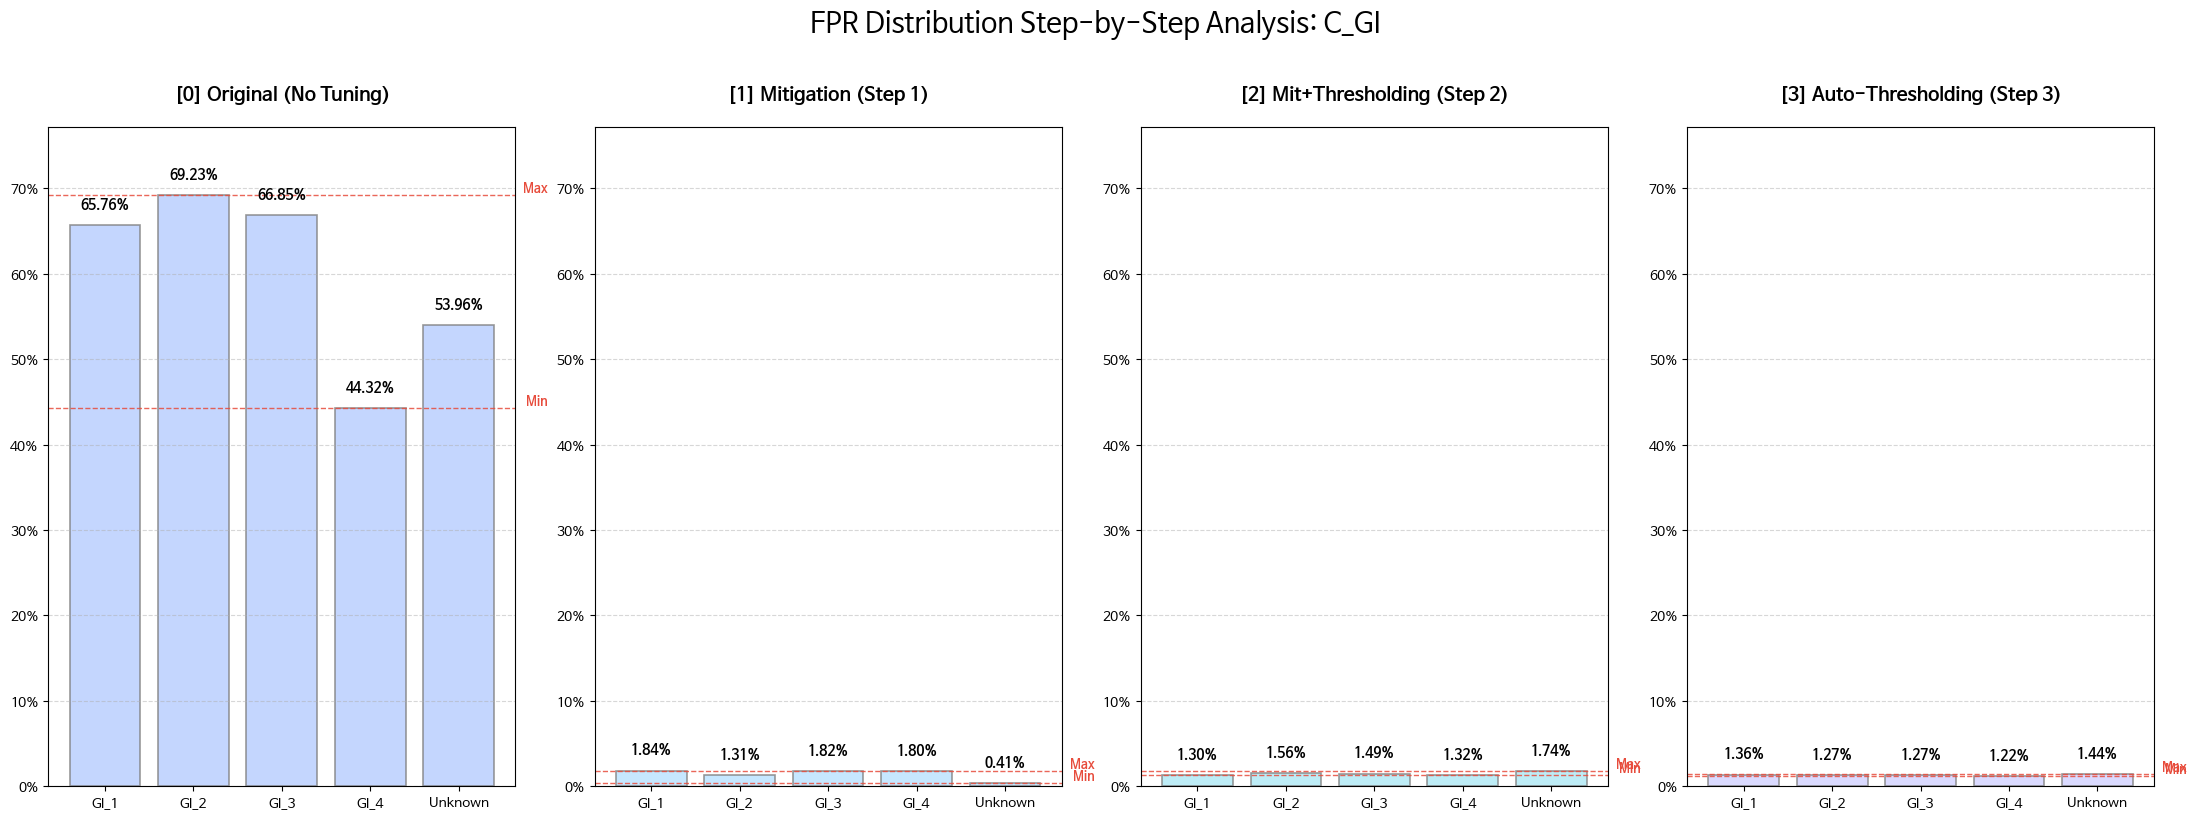

In [ ]:
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

##### `C_IE_T`

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
          selection_rate       tpr       tnr       fpr       fnr
C_IE_T                                                          
C_IE_T_1        0.727941  0.898811  0.317276  0.682724  0.101189
C_IE_T_2        0.601555  0.820342  0.444548  0.555452  0.179658
C_IE_T_3        0.467243  0.710476  0.573846  0.426154  0.289524
C_IE_T_4        0.391519  0.633128  0.642951  0.357049  0.366872
Unknown         0.572879  0.827195  0.460370  0.539630  0.172805
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.336422
tpr               0.265683
tnr               0.325675
fpr               0.325675
fnr               0.265683
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습

⚖️ Fairlearn 재학습 중...
       [Fairlearn 모델 1차 학습 성능 결과]        
F1-Score: 0.1364
PR-AUC: 0.20

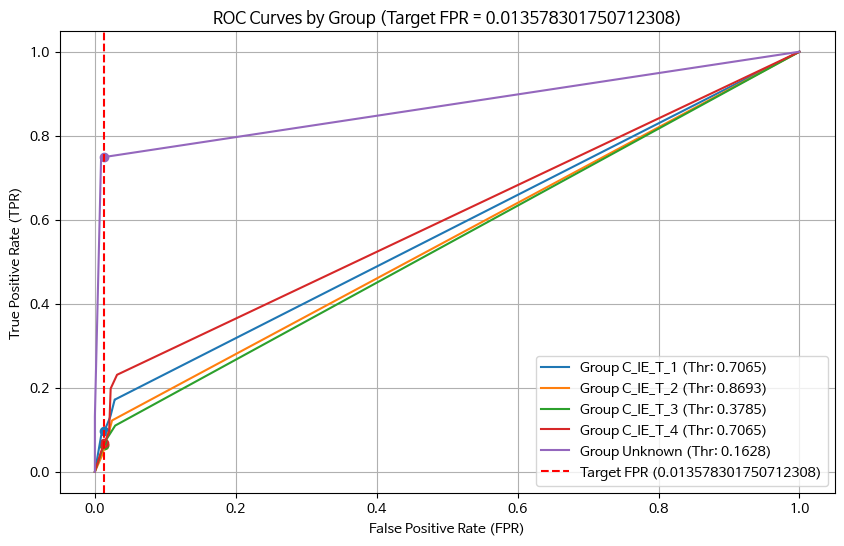

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1153
PR-AUC : 0.2071
Recall    : 0.0645
Precision : 0.5409

       [최종 - 집단별 임계값]       
Group C_IE_T_1: 0.7065
Group C_IE_T_2: 0.8693
Group C_IE_T_3: 0.3785
Group C_IE_T_4: 0.7065
Group Unknown: 0.1628

       [최종 - 연령대별 공정성 세부 지표]       
          selection_rate       tpr       tnr       fpr       fnr
C_IE_T                                                          
C_IE_T_1        0.018576  0.053104  0.990561  0.009439  0.946896
C_IE_T_2        0.022666  0.073828  0.988115  0.011885  0.926172
C_IE_T_3        0.020040  0.071238  0.988609  0.011391  0.928762
C_IE_T_4        0.015964  0.063269  0.990785  0.009215  0.936731
Unknown         0.017360  0.062323  0.988519  0.011481  0.937677

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.006702
tpr               0.020723
tnr               0.002670
fpr               0.002670
fnr               0.020723
dtype: float64

 ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.

 [Step 0] Base Model (보정 전) 학습 결과



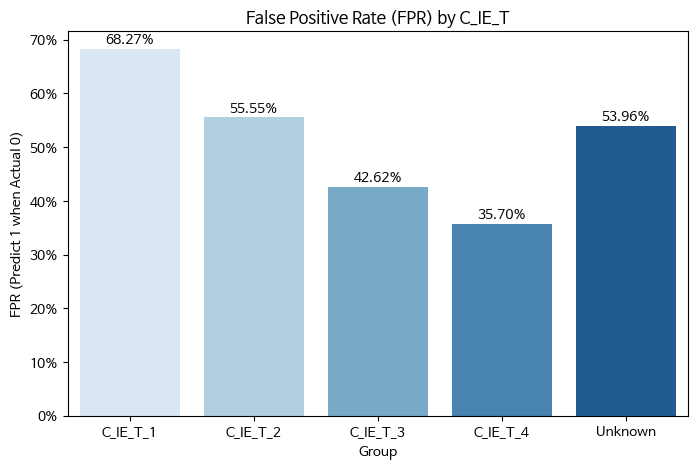

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.727900,72.79%,89.88%,68.27%,25.84%
1,C_IE_T_2,0.174000,0.601600,60.16%,82.03%,55.55%,23.73%
2,C_IE_T_3,0.144500,0.467200,46.72%,71.05%,42.62%,21.97%
3,C_IE_T_4,0.124900,0.391500,39.15%,63.31%,35.70%,20.19%
4,Unknown,0.115600,0.572900,57.29%,82.72%,53.96%,16.70%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



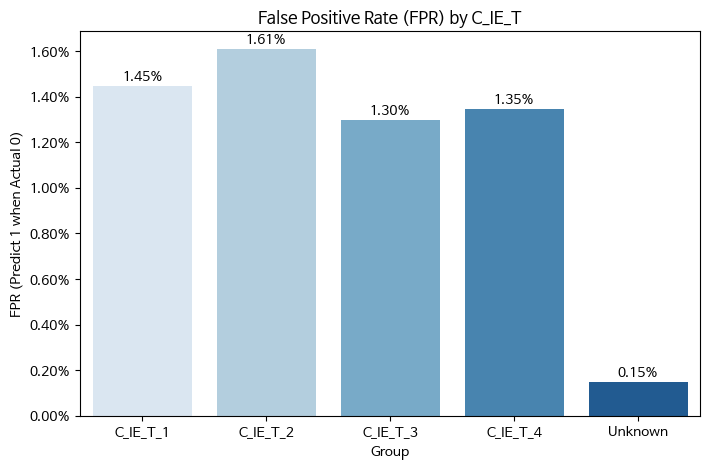

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.027200,2.72%,7.53%,1.45%,57.93%
1,C_IE_T_2,0.174000,0.029100,2.91%,9.09%,1.61%,54.36%
2,C_IE_T_3,0.144500,0.022100,2.21%,7.62%,1.30%,49.75%
3,C_IE_T_4,0.124900,0.021700,2.17%,7.91%,1.35%,45.57%
4,Unknown,0.115600,0.002600,0.26%,1.13%,0.15%,50.00%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



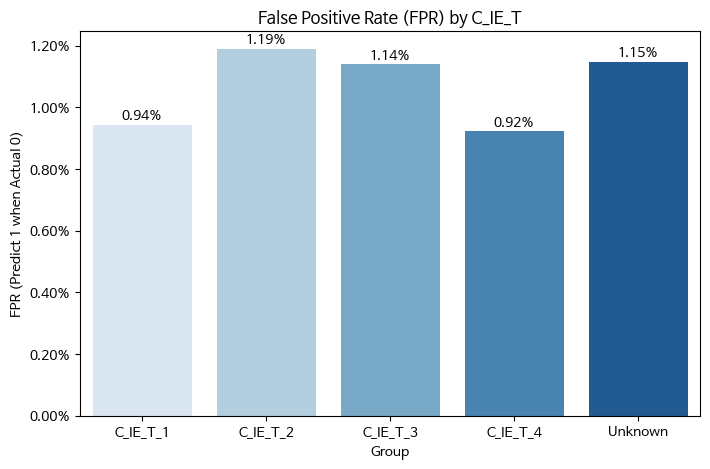

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.018600,1.86%,5.31%,0.94%,59.82%
1,C_IE_T_2,0.174000,0.022700,2.27%,7.38%,1.19%,56.69%
2,C_IE_T_3,0.144500,0.020000,2.00%,7.12%,1.14%,51.37%
3,C_IE_T_4,0.124900,0.016000,1.60%,6.33%,0.92%,49.48%
4,Unknown,0.115600,0.017400,1.74%,6.23%,1.15%,41.51%


In [ ]:
var_name = 'c_ie_t'
x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        model, threshold
        )


       [공통 임계값]       
0.13999999999999999

       [연령대별 공정성 세부 지표]       
          selection_rate       tpr       tnr       fpr       fnr
C_IE_T                                                          
C_IE_T_1        0.727941  0.898811  0.317276  0.682724  0.101189
C_IE_T_2        0.601555  0.820342  0.444548  0.555452  0.179658
C_IE_T_3        0.467243  0.710476  0.573846  0.426154  0.289524
C_IE_T_4        0.391519  0.633128  0.642951  0.357049  0.366872
Unknown         0.572879  0.827195  0.460370  0.539630  0.172805
       [학습 전 결과]       
F1-Score  : 0.3575
PR-AUC : 0.3432
Recall    : 0.7863
Precision : 0.2314
공통 임계값: 0.13999999999999999

집단 간 최대 격차 (Max Gap)
selection_rate    0.336422
tpr               0.265683
tnr               0.325675
fpr               0.325675
fnr               0.265683
dtype: float64
       [최종 모델 전체 성능 결과]        
F1-Score  : 0.1306
PR-AUC : 0.1884
Recall    : 0.0745
Precision : 0.5260

       [집단별 임계값]       
연령대: C_IE_T_1 | 추정 임계값: 0.3880
연령대: C_IE_T

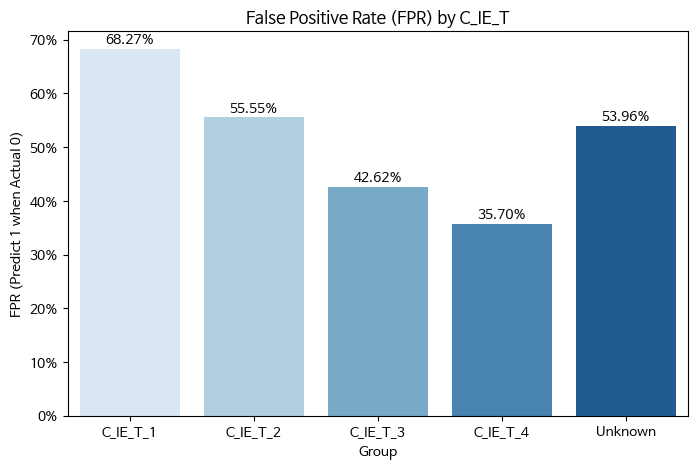

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.727900,72.79%,89.88%,68.27%,25.84%
1,C_IE_T_2,0.174000,0.601600,60.16%,82.03%,55.55%,23.73%
2,C_IE_T_3,0.144500,0.467200,46.72%,71.05%,42.62%,21.97%
3,C_IE_T_4,0.124900,0.391500,39.15%,63.31%,35.70%,20.19%
4,Unknown,0.115600,0.572900,57.29%,82.72%,53.96%,16.70%



 [Step 3] Base Model (보정 전) 학습 결과


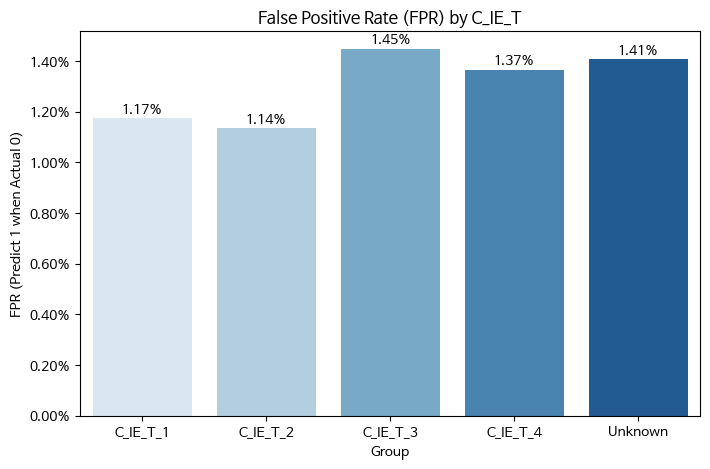

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.024400,2.44%,7.21%,1.17%,61.90%
1,C_IE_T_2,0.174000,0.022500,2.25%,7.54%,1.14%,58.33%
2,C_IE_T_3,0.144500,0.024900,2.49%,8.65%,1.45%,50.22%
3,C_IE_T_4,0.124900,0.021000,2.10%,7.25%,1.37%,43.08%
4,Unknown,0.115600,0.014400,1.44%,1.70%,1.41%,13.64%


In [ ]:
var_name = 'c_ie_t'
y_pred_final = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

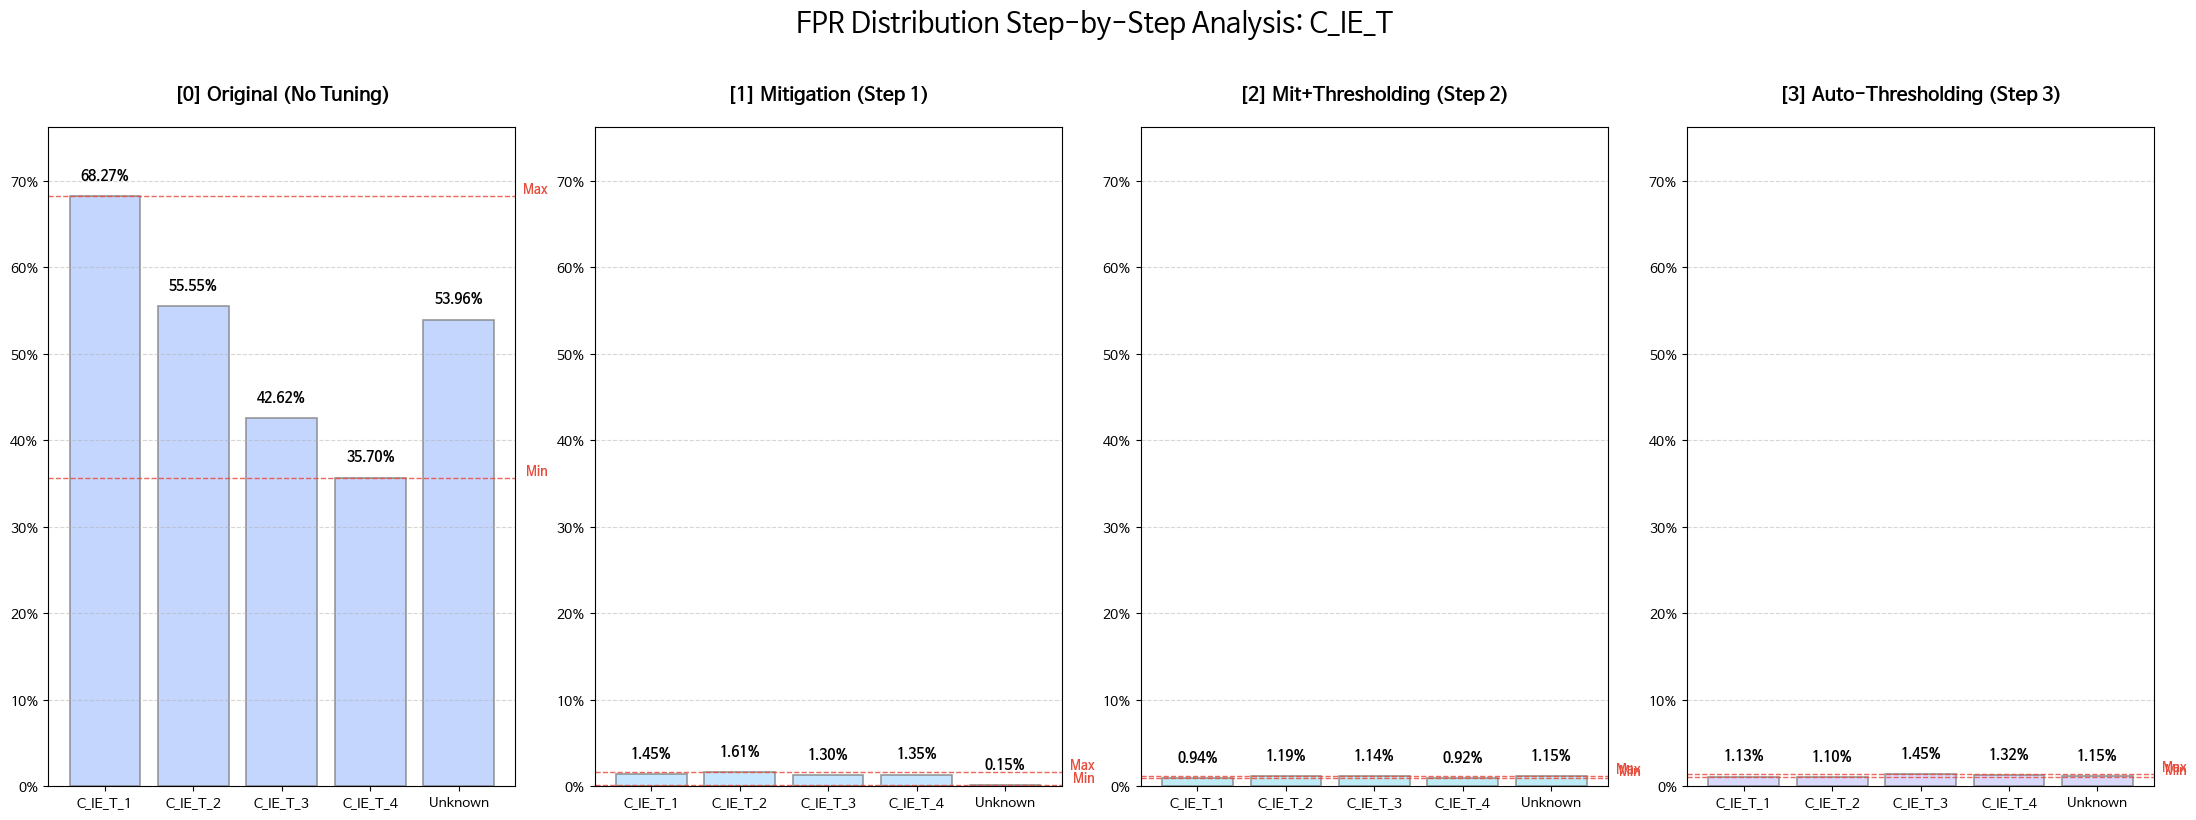

In [ ]:
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)